# 01. ESS 배터리 데이터 점검 및 탐색적 데이터 분석 (EDA)



## 1. 프로젝트 개요 및 초기 데이터 역할 정의

### 데이터 파일 구성 (.mat)
| 파일명 | 크기 | 식별명 | 셀 수 | 역할 및 적용 범위 |
| :--- | :--- | :--- | :---: | :--- |
|  | ~2.8 GB | **Batch 1** | 46 | **Train & 내부 Hold-out 검증용** (모델 개발 메인 데이터) |
|  | ~1.9 GB | **Batch 2** | 47 | **최종 일반화 Test용** (모델 완성 후 1회 평가) |
|  | ~3.0 GB | **Batch 3** | 46 | **Q1 배치 비교용** (후속 분석에도 활용) |
|  | ~85 MB | **Extra** | - | **본 과제 제외** (충전 최적화 연구 데이터) |

> **데이터 분석 및 모델링 원칙**:
> 1. **모델 개발**: 피처·모델 선택과 내부 검증은 Batch 1에서 수행합니다.
> 2. **Q1 배치 비교**: Batch 1·2·3의 수명 분포를 기술적으로 비교합니다. Batch 2의 라벨 분포는 이번 분석에서 열람했으므로 완전한 블라인드 테스트는 아닙니다.
> 3. **최종 평가**: Batch 2의 Q1 통계를 모델·피처 선택이나 튜닝에 사용하지 않고, 성능 평가는 모델 확정 후 진행합니다.

In [134]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 프로젝트 루트 등록
project_root = os.path.abspath("..//")
if project_root not in sys.path:
    sys.path.append(project_root)

import importlib
import src.preprocess as preprocess
preprocess = importlib.reload(preprocess)
load_batch_summary = preprocess.load_batch_summary

# 시각화 스타일 설정
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["font.family"] = "AppleGothic" if sys.platform == "darwin" else "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False

# 소수점 표시 옵션 설정 (4자리 고정)
pd.set_option("display.float_format", "{:.4f}".format)

DATA_DIR = os.path.join(project_root, "data")
print(f"Data Directory: {DATA_DIR}")

Data Directory: /Users/skala_yh/DS_miniproject/data


## 2. Batch 1 데이터 로드 및 초기 지표 추출

> 💡 **핵심 가이드: 왜 "Cycle 2 ~ 100" 사이클 구간을 분석하는가?**
> 1. **시작점이 Cycle 2인 이유 (데이터 구조적 특성)**:
>    - 원본 데이터셋에서 **Cycle 1은 모든 요약 필드(방전용량, 충전용량, 저항, 온도, 충전시간)가 `0.0`으로 기록**되어 있습니다.
>    - 따라서 첫 번째 완전한 정상 측정이 계측된 **Cycle 2(인덱스 1)가 배터리의 실질적인 초기 기준점**이 됩니다.
> 2. **종료점이 Cycle 100인 이유 (과제 필수 제약조건)**:
>    - [PROJECT_OVERVIEW.md] 규정: 장기 수명을 조기에 진단하기 위해 **회귀 모델 입력은 반드시 "초기 100사이클" 이내로 제한**됩니다 (100사이클 이후 데이터 사용은 데이터 누수/규정 위반).
>    - 따라서 **Cycle 2(최초 정상점) 대비 Cycle 100(조기 진단 마감점) 사이의 변화량(`delta_q`, `delta_ir`) 및 통계량**이 수명 예측의 핵심 조기 열화 신호가 됩니다.

- 원시 요약 데이터(`summary`)의 모든 필드를 포함하여 초기 100사이클 지표를 전수 추출합니다.
- 포함 필드: 방전용량(`QDischarge`), 충전용량(`QCharge`), 쿨롱효율(`CE = Qd/Qc`), 내부저항(`IR`), 온도(`Tavg`, `Tmin`, `Tmax`), 충전시간(`chargetime`).


In [135]:
b1_path = os.path.join(DATA_DIR, "2017-05-12_batchdata_updated_struct_errorcorrect.mat")
df_b1 = load_batch_summary(b1_path, "Batch1")
print(f"Batch 1 로드 셀 수: {len(df_b1)}개")

def extract_full_summary_features(df):
    """원시 summary 구조체의 모든 초기(Cycle 2 ~ 100, index 1:100) 지표 추출"""
    rows = []
    for _, r in df.iterrows():
        qd = r["QDischarge"]
        qc = r["QCharge"]
        ir = r["IR"]
        tmax = r["Tmax"]
        tavg = r["Tavg"]
        tmin = r["Tmin"]
        ch_time = r["chargetime"]
        
        # 1. 용량 지표 (Cycle 2 및 Cycle 100)
        q_init = qd[1] if len(qd) > 1 else np.nan
        qc_init = qc[1] if len(qc) > 1 else np.nan
        ce_init = (q_init / qc_init * 100) if (qc_init and not np.isnan(qc_init)) else np.nan
        
        q_100 = qd[99] if len(qd) > 99 else np.nan
        qc_100 = qc[99] if len(qc) > 99 else np.nan
        ce_100 = (q_100 / qc_100 * 100) if (qc_100 and not np.isnan(qc_100)) else np.nan
        delta_q = (q_100 - q_init) if (not np.isnan(q_100) and not np.isnan(q_init)) else np.nan
        
        # 2. 내부저항 지표 (IR)
        ir_init = ir[1] if len(ir) > 1 else np.nan
        ir_100 = ir[99] if len(ir) > 99 else np.nan
        delta_ir = (ir_100 - ir_init) if (not np.isnan(ir_100) and not np.isnan(ir_init)) else np.nan
        
        # 3. 온도 지표 (정상 Cycle 2 ~ 100 구간 통계: index 1:100)
        t_min_100 = np.min(tmin[1:100]) if len(tmin) >= 100 else np.nan
        t_avg_100 = np.mean(tavg[1:100]) if len(tavg) >= 100 else np.nan
        t_max_100 = np.max(tmax[1:100]) if len(tmax) >= 100 else np.nan
        delta_t = (t_max_100 - t_min_100) if (not np.isnan(t_max_100) and not np.isnan(t_min_100)) else np.nan
        
        # 4. 충전 시간 지표 (Cycle 2 ~ 100)
        ch_init = ch_time[1] if len(ch_time) > 1 else np.nan
        ch_100 = ch_time[99] if len(ch_time) > 99 else np.nan
        ch_avg = np.mean(ch_time[1:100]) if len(ch_time) >= 100 else np.nan
        
        rows.append({
            "cell_id": r["cell_id"],
            "policy": r["policy"],
            "cycle_life": r["cycle_life"],
            "n_cycles": r["n_cycles"],
            "q_init_c2": q_init,
            "qc_init_c2": qc_init,
            "ce_init_pct": ce_init,
            "q_c100": q_100,
            "qc_c100": qc_100,
            "ce_c100_pct": ce_100,
            "delta_q_100_2": delta_q,
            "ir_init": ir_init,
            "ir_c100": ir_100,
            "delta_ir_100_2": delta_ir,
            "t_min_100": t_min_100,
            "t_avg_100": t_avg_100,
            "t_max_100": t_max_100,
            "delta_t_100": delta_t,
            "ch_time_init_min": ch_init,
            "ch_time_c100_min": ch_100,
            "ch_time_avg_min": ch_avg
        })
    return pd.DataFrame(rows)

feat_b1 = extract_full_summary_features(df_b1)


Batch 1 로드 셀 수: 46개


## 3. [표] Batch 1 종합 기초 통계량 
- count는 정수로 표기하며, 나머지 연속형 통계량은 소수점 넷째 자리로 표기합니다.
- 각 변수의 한글 명칭과 측정 단위가 함께 표기하여 직관적으로 파악할 수 있습니다.

In [136]:
var_map = {
    'cycle_life': ('[Target] 수명 (전체 사이클 수)', 'Cycle', '타깃 (Y)'),
    'n_cycles': ('[사후정보] 기록된 총 사이클 수', 'Cycle', '사후 유출정보 (제외)'),
    'q_init_c2': ('초기 방전용량 (2사이클)', 'Ah', '입력 피처 후보'),
    'qc_init_c2': ('초기 충전용량 (2사이클)', 'Ah', '입력 피처 후보'),
    'ce_init_pct': ('초기 쿨롱효율 (Qd/Qc)', '%', '입력 피처 후보'),
    'q_c100': ('100사이클 방전용량', 'Ah', '입력 피처 후보'),
    'qc_c100': ('100사이클 충전용량', 'Ah', '입력 피처 후보'),
    'ce_c100_pct': ('100사이클 쿨롱효율', '%', '입력 피처 후보'),
    'delta_q_100_2': ('용량 변화량 (100C - 2C)', 'Ah', '입력 피처 후보'),
    'ir_init': ('초기 내부저항 (2사이클)', 'Ω', '입력 피처 후보'),
    'ir_c100': ('100사이클 내부저항', 'Ω', '입력 피처 후보'),
    'delta_ir_100_2': ('내부저항 변화량', 'Ω', '입력 피처 후보'),
    't_min_100': ('초기 100사이클 최저온도', '°C', '입력 피처 후보'),
    't_avg_100': ('초기 100사이클 평균온도', '°C', '입력 피처 후보'),
    't_max_100': ('초기 100사이클 최고온도', '°C', '입력 피처 후보'),
    'delta_t_100': ('온도 편차 (최고 - 최저)', '°C', '입력 피처 후보'),
    'ch_time_init_min': ('초기 충전시간 (2사이클)', '분', '입력 피처 후보'),
    'ch_time_c100_min': ('100사이클 충전시간', '분', '입력 피처 후보'),
    'ch_time_avg_min': ('초기 100사이클 평균충전시간', '분', '입력 피처 후보')
}

def format_describe_table(df):
    """count 정수, 결측률/사분위수/통계량 소수점 4자리, 구분/한글명/단위 표기"""
    desc = df.describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']].copy()
    desc['count'] = desc['count'].astype(int)
    desc.insert(0, '구분', desc.index.map(lambda x: var_map.get(x, ('', '', ''))[2]))
    desc.insert(1, '변수 한글명', desc.index.map(lambda x: var_map.get(x, (x, '', ''))[0]))
    desc.insert(2, '단위', desc.index.map(lambda x: var_map.get(x, ('', '', ''))[1]))
    desc.insert(4, '결측률(%)', desc.index.map(lambda x: (df[x].isna().sum() / len(df)) * 100.0))
    desc = desc.rename(columns={'25%': 'Q1(25%)', '50%': '중앙값(50%)', '75%': 'Q3(75%)'})
    
    return desc.style.format({
        'count': '{:d}',
        '결측률(%)': '{:.4f}',
        'mean': '{:.4f}',
        'std': '{:.4f}',
        'min': '{:.4f}',
        'Q1(25%)': '{:.4f}',
        '중앙값(50%)': '{:.4f}',
        'Q3(75%)': '{:.4f}',
        'max': '{:.4f}'
    })

print('=== Batch 1 (학습/검증용) 종합 기초 통계량 (N=46) ===')
display(format_describe_table(feat_b1))


=== Batch 1 (학습/검증용) 종합 기초 통계량 (N=46) ===


,구분,변수 한글명,단위,count,결측률(%),mean,std,min,Q1(25%),중앙값(50%),Q3(75%),max
cycle_life,타깃 (Y),[Target] 수명 (전체 사이클 수),Cycle,46,0.0000,844.7174,184.6292,534.0000,703.2500,858.5000,914.2500,1227.0000
n_cycles,사후 유출정보 (제외),[사후정보] 기록된 총 사이클 수,Cycle,46,0.0000,843.7174,184.6292,533.0000,702.2500,857.5000,913.2500,1226.0000
q_init_c2,입력 피처 후보,초기 방전용량 (2사이클),Ah,46,0.0000,1.0781,0.0077,1.0538,1.0749,1.0787,1.0816,1.0946
qc_init_c2,입력 피처 후보,초기 충전용량 (2사이클),Ah,46,0.0000,1.0780,0.0078,1.0529,1.0747,1.0789,1.0814,1.0947
ce_init_pct,입력 피처 후보,초기 쿨롱효율 (Qd/Qc),%,46,0.0000,100.0058,0.0417,99.9363,99.9704,99.9962,100.0364,100.1030
q_c100,입력 피처 후보,100사이클 방전용량,Ah,46,0.0000,1.0807,0.0078,1.0600,1.0771,1.0815,1.0848,1.0958
qc_c100,입력 피처 후보,100사이클 충전용량,Ah,46,0.0000,1.0804,0.0078,1.0594,1.0769,1.0811,1.0847,1.0954
ce_c100_pct,입력 피처 후보,100사이클 쿨롱효율,%,46,0.0000,100.0286,0.0237,99.9875,100.0142,100.0251,100.0392,100.0936
delta_q_100_2,입력 피처 후보,용량 변화량 (100C - 2C),Ah,46,0.0000,0.0026,0.0030,-0.0114,0.0019,0.0028,0.0043,0.0066
ir_init,입력 피처 후보,초기 내부저항 (2사이클),Ω,46,0.0000,0.0167,0.0006,0.0153,0.0165,0.0167,0.0169,0.0199


## 4. Batch 1 데이터 특성 및 분석 시사점

### 주요 변수 분포와 극단값 후보

- Q1. 각 변수의 값이 어디에 모이고, 다른 셀과 크게 다른 관측값이 있는가?
- A1. Batch 1의 셀별 요약값 46개만 사용한다. 왼쪽은 값 구간별 셀 수, 오른쪽은 중앙값·사분위 범위와 실제 셀 46개의 위치다.
    박스플롯 바깥 점은 검토 후보일 뿐 측정 오류나 제거 대상으로 확정하지 않는다. 
    `cycle_life`는 타깃이며, `n_cycles`는 사후 정보이므로 입력 변수 분포에 포함하지 않는다.


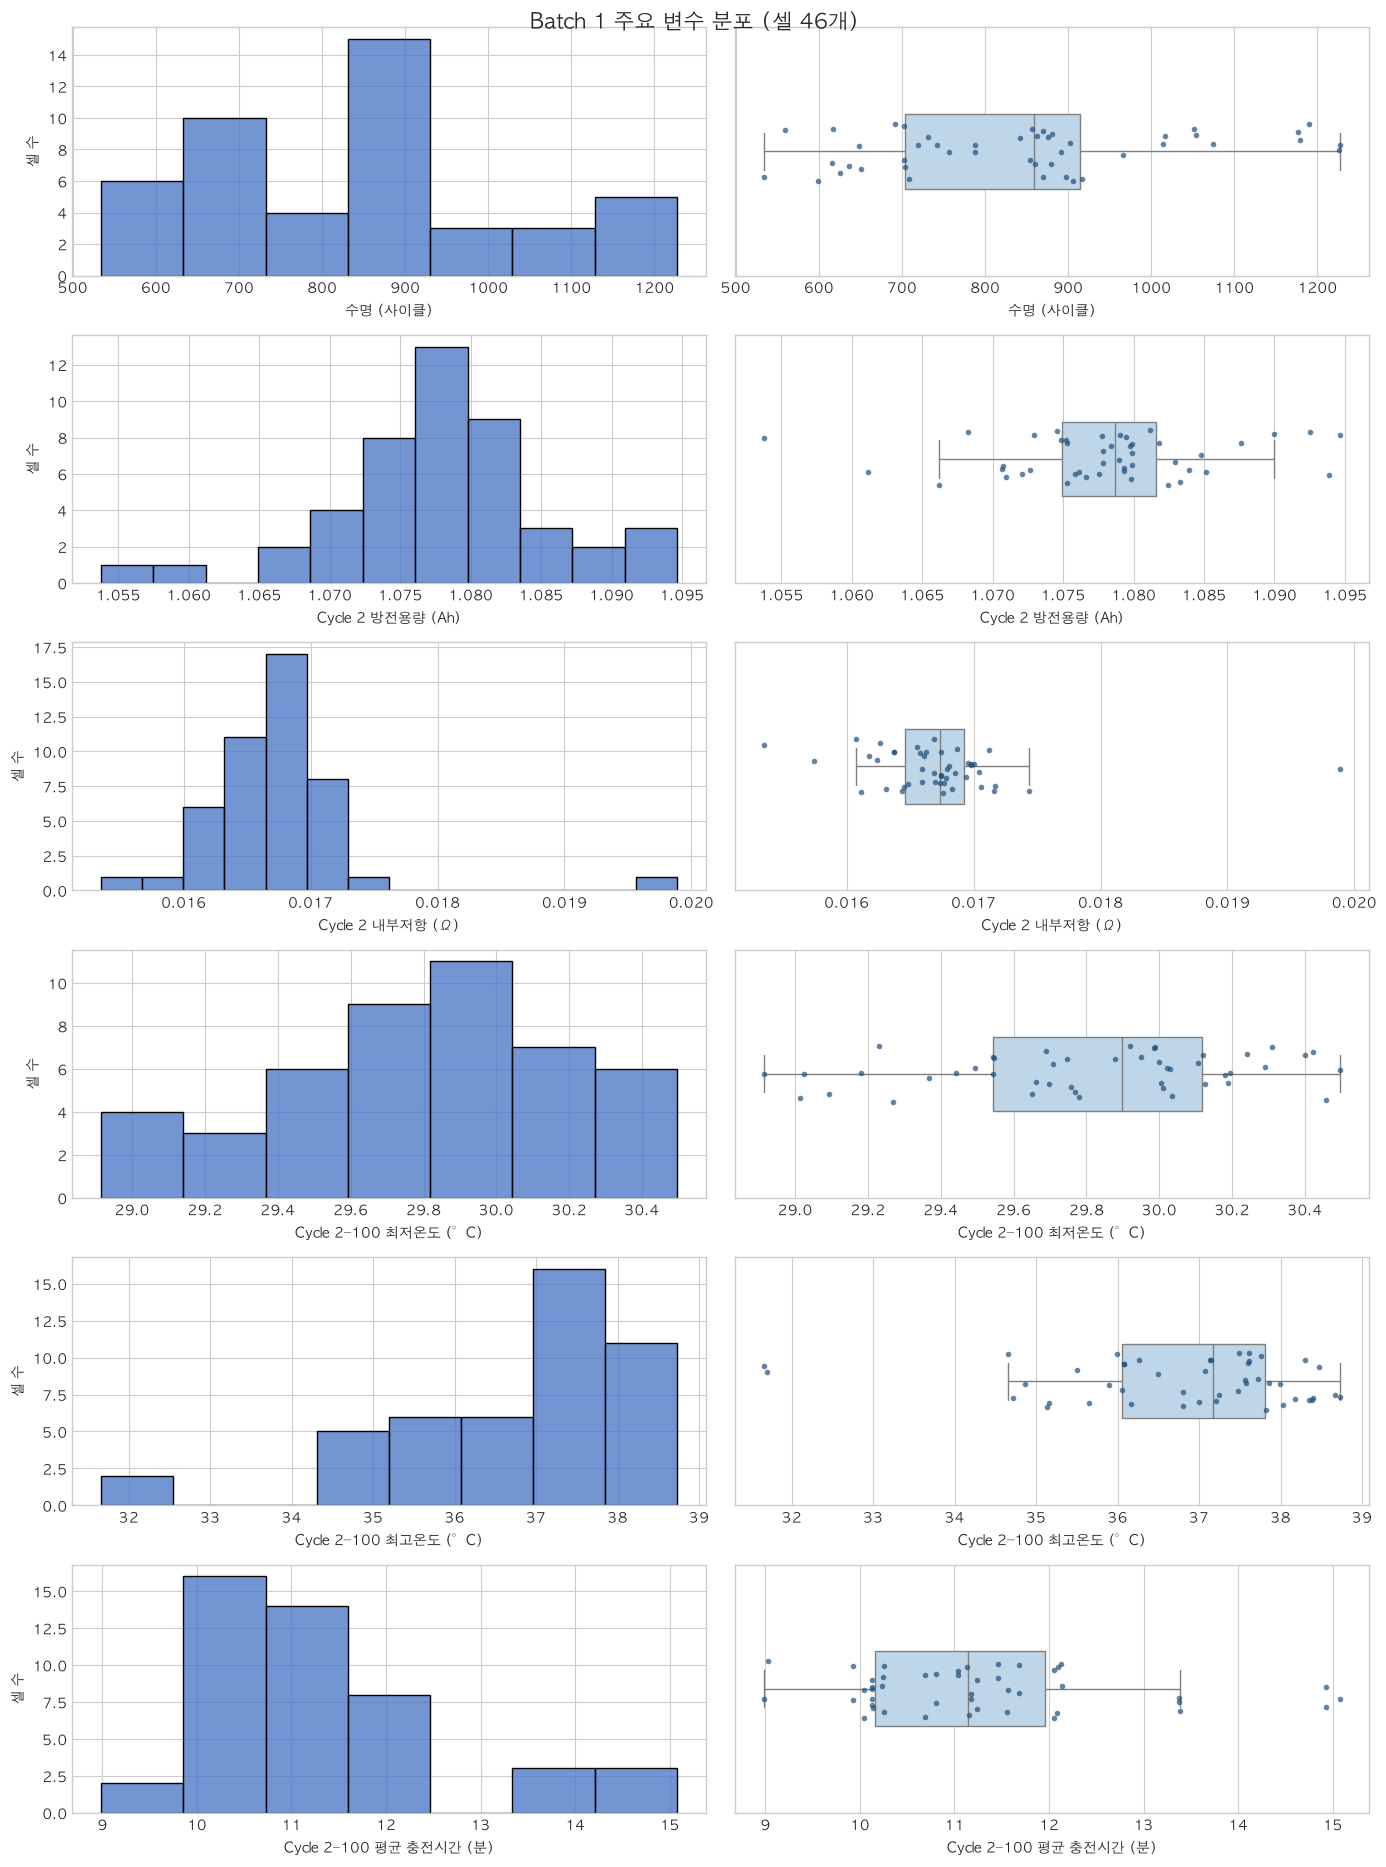

In [137]:
distribution_vars = [
    ("cycle_life", "수명", "사이클"),
    ("q_init_c2", "Cycle 2 방전용량", "Ah"),
    ("ir_init", "Cycle 2 내부저항", "Ω"),
    ("t_min_100", "Cycle 2–100 최저온도", "°C"),
    ("t_max_100", "Cycle 2–100 최고온도", "°C"),
    ("ch_time_avg_min", "Cycle 2–100 평균 충전시간", "분"),
]

fig, axes = plt.subplots(len(distribution_vars), 2, figsize=(14, 19))
for row, (column, label, unit) in enumerate(distribution_vars):
    values = feat_b1[column].dropna()
    sns.histplot(values, bins="auto", ax=axes[row, 0], color="#4472c4")
    axes[row, 0].set(xlabel=f"{label} ({unit})", ylabel="셀 수")
    sns.boxplot(x=values, ax=axes[row, 1], color="#b7d7ef", fliersize=0, width=0.3)
    sns.stripplot(x=values, ax=axes[row, 1], color="#1f4e79", size=4, jitter=0.12, alpha=0.7)
    axes[row, 1].set(xlabel=f"{label} ({unit})", ylabel="")
fig.suptitle("Batch 1 주요 변수 분포 (셀 46개)", fontsize=15)
plt.tight_layout()
plt.show()


### IQR 기준 특이값 후보와 원본 위치

각 변수의 Q1−1.5×IQR, Q3+1.5×IQR 바깥 값을 **검토 후보**로 표시한다. 한 행은 하나의 변수·셀 조합이며, 원본 사이클과 주변 값으로 단발성 급변인지 살핀다. 이 기준은 측정 오류 판정이나 삭제 규칙이 아니다. 타깃 수명은 분포 확인만 하고, 후보 피처 선정에 사용하지 않는다.


In [138]:
outlier_rows = []
for column, label, unit in distribution_vars:
    q1, q3 = feat_b1[column].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    flagged = feat_b1.loc[(feat_b1[column] < lower) | (feat_b1[column] > upper)]
    for _, feature_row in flagged.iterrows():
        raw = df_b1.loc[df_b1["cell_id"] == feature_row["cell_id"]].iloc[0]
        early = (raw["cycles"] >= 2) & (raw["cycles"] <= 100)
        if column == "q_init_c2":
            evidence = f"Cycle 2: {raw['QDischarge'][1]:.6f}; Cycle 3: {raw['QDischarge'][2]:.6f} Ah"
        elif column == "ir_init":
            evidence = f"Cycle 2: {raw['IR'][1]:.6f}; Cycle 3: {raw['IR'][2]:.6f} Ω"
        elif column in ("t_min_100", "t_max_100"):
            field = "Tmin" if column == "t_min_100" else "Tmax"
            indices = np.flatnonzero(early)
            position = indices[np.argmin(raw[field][early]) if field == "Tmin" else np.argmax(raw[field][early])]
            neighbors = [j for j in (position - 1, position + 1) if 1 <= j < len(raw["cycles"])]
            nearby = ", ".join(f"C{int(raw['cycles'][j])} {raw[field][j]:.3f}" for j in neighbors)
            evidence = f"Cycle {int(raw['cycles'][position])}: {raw[field][position]:.6f} °C; 이웃 {nearby} °C"
        elif column == "ch_time_avg_min":
            indices = np.flatnonzero(early)
            position = indices[np.argmax(raw["chargetime"][early])]
            evidence = (f"Cycle {int(raw['cycles'][position])}: {raw['chargetime'][position]:.3f}분; "
                        f"구간 중앙값: {np.median(raw['chargetime'][early]):.3f}분")
        else:
            evidence = "수명 라벨 (셀별 1개)"
        outlier_rows.append({
            "변수": label,
            "셀 ID": feature_row["cell_id"],
            "요약값": float(feature_row[column]),
            "하한": float(lower),
            "상한": float(upper),
            "원본 확인": evidence,
            "판정": "원인 미확인·원본 유지",
        })

outlier_candidates = pd.DataFrame(outlier_rows)
outlier_candidates.to_csv(os.path.join(project_root, "results", "batch1_outlier_candidates.csv"), index=False)
print(f"IQR 검토 후보: {len(outlier_candidates)}개 변수·셀 조합, {outlier_candidates['셀 ID'].nunique()}개 셀")
display(outlier_candidates.style.format({"요약값": "{:.6f}", "하한": "{:.6f}", "상한": "{:.6f}"}))


IQR 검토 후보: 13개 변수·셀 조합, 11개 셀


,변수,셀 ID,요약값,하한,상한,원본 확인,판정
0,Cycle 2 방전용량,Batch1_c07,1.093864,1.064871,1.091677,Cycle 2: 1.093864; Cycle 3: 1.095110 Ah,원인 미확인·원본 유지
1,Cycle 2 방전용량,Batch1_c11,1.053779,1.064871,1.091677,Cycle 2: 1.053779; Cycle 3: 1.055032 Ah,원인 미확인·원본 유지
2,Cycle 2 방전용량,Batch1_c15,1.061124,1.064871,1.091677,Cycle 2: 1.061124; Cycle 3: 1.062743 Ah,원인 미확인·원본 유지
3,Cycle 2 방전용량,Batch1_c31,1.094639,1.064871,1.091677,Cycle 2: 1.094639; Cycle 3: 1.095935 Ah,원인 미확인·원본 유지
4,Cycle 2 방전용량,Batch1_c33,1.092491,1.064871,1.091677,Cycle 2: 1.092491; Cycle 3: 1.093831 Ah,원인 미확인·원본 유지
5,Cycle 2 내부저항,Batch1_c18,0.019886,0.015763,0.017615,Cycle 2: 0.019886; Cycle 3: 0.019886 Ω,원인 미확인·원본 유지
6,Cycle 2 내부저항,Batch1_c20,0.015741,0.015763,0.017615,Cycle 2: 0.015741; Cycle 3: 0.015663 Ω,원인 미확인·원본 유지
7,Cycle 2 내부저항,Batch1_c21,0.015349,0.015763,0.017615,Cycle 2: 0.015349; Cycle 3: 0.015273 Ω,원인 미확인·원본 유지
8,Cycle 2–100 최고온도,Batch1_c03,31.691414,33.442812,40.420215,"Cycle 67: 31.691414 °C; 이웃 C66 31.545, C68 31.587 °C",원인 미확인·원본 유지
9,Cycle 2–100 최고온도,Batch1_c31,31.658901,33.442812,40.420215,"Cycle 55: 31.658901 °C; 이웃 C54 31.621, C56 31.529 °C",원인 미확인·원본 유지


### 분포 후보 원본 대조 결과

- IQR 기준에서 **11개 셀, 13건**이 검토 대상으로 나왔다. 주변 사이클을 확인했지만 오류인지는 아직 알 수 없다.
- 특히 3개 셀의 **Cycle 13 충전시간은 약 419분**으로, 평균을 크게 높였다. 이유를 확인할 때까지 원본을 유지하고 충전시간 피처 사용은 보류한다.


### 추가 관측과 분석 시사점

#### 쿨롱 효율(`ce_c100_pct`) 실측치 관측 및 가설 구분
- **관측 사실**: 100사이클 시점에서 46개 중 40개 셀의 쿨롱 효율이 100%를 미세하게 초과하며, 최댓값은 100.0936% (`Batch1_c21`)로 관측됩니다.
- **주의 (가설과 사실의 구분)**: 일반적인 화학 반응에서 100% 초과는 드물지만, 원논문 장비의 구체적 오차 전파나 측정 정의를 추가 확인하기 전에는 잔류 전하나 장비 오차를 원인으로 단정하지 않고 **미검증 가설**로 둡니다. 임의로 100%로 보정하지 않고 실측치 그대로 보존합니다.

#### 초기 100사이클 온도 지표
- **정상 범위 확인**: Cycle 2–100 구간으로 인덱싱을 보정한 결과, 최저온도(`t_min_100`)는 **28.9148 ~ 30.4957°C**(평균 29.8146°C)로 30°C 항온 챔버 환경에 완전히 부합합니다.
- **온도 편차(`delta_t_100`)**: 최고온도와 최저온도의 차이는 **2.0093 ~ 9.0348°C**로 최고온도와 값이 다르므로 후보로 남깁니다. 예측에 유용한지는 아직 확인하지 않았습니다.

#### 타깃 및 사후 정보 분리
- 통계표에 표시된 `cycle_life`는 **예측 타깃(Y)**이며, `n_cycles`는 실험 종료 후 기록된 총 사이클 수(사후 정보)입니다.
- 모델 학습 피처(X)를 구성할 때는 이 두 변수를 엄격히 제외하고, 순수한 조기 물리 관측치 17개 후보군만을 사용합니다.


### 초기 요약값과 수명의 관계

분포를 확인한 뒤 Batch 1에서 초기 용량·저항·최고온도와 수명의 관계를 산점도로 살핀다. Pearson 상관계수는 선형 관계의 크기만 보여주며 예측력이나 원인을 확정하지 않는다. 충전시간 색상은 Cycle 13 장시간 기록의 영향을 받을 수 있어 참고용으로만 해석한다.


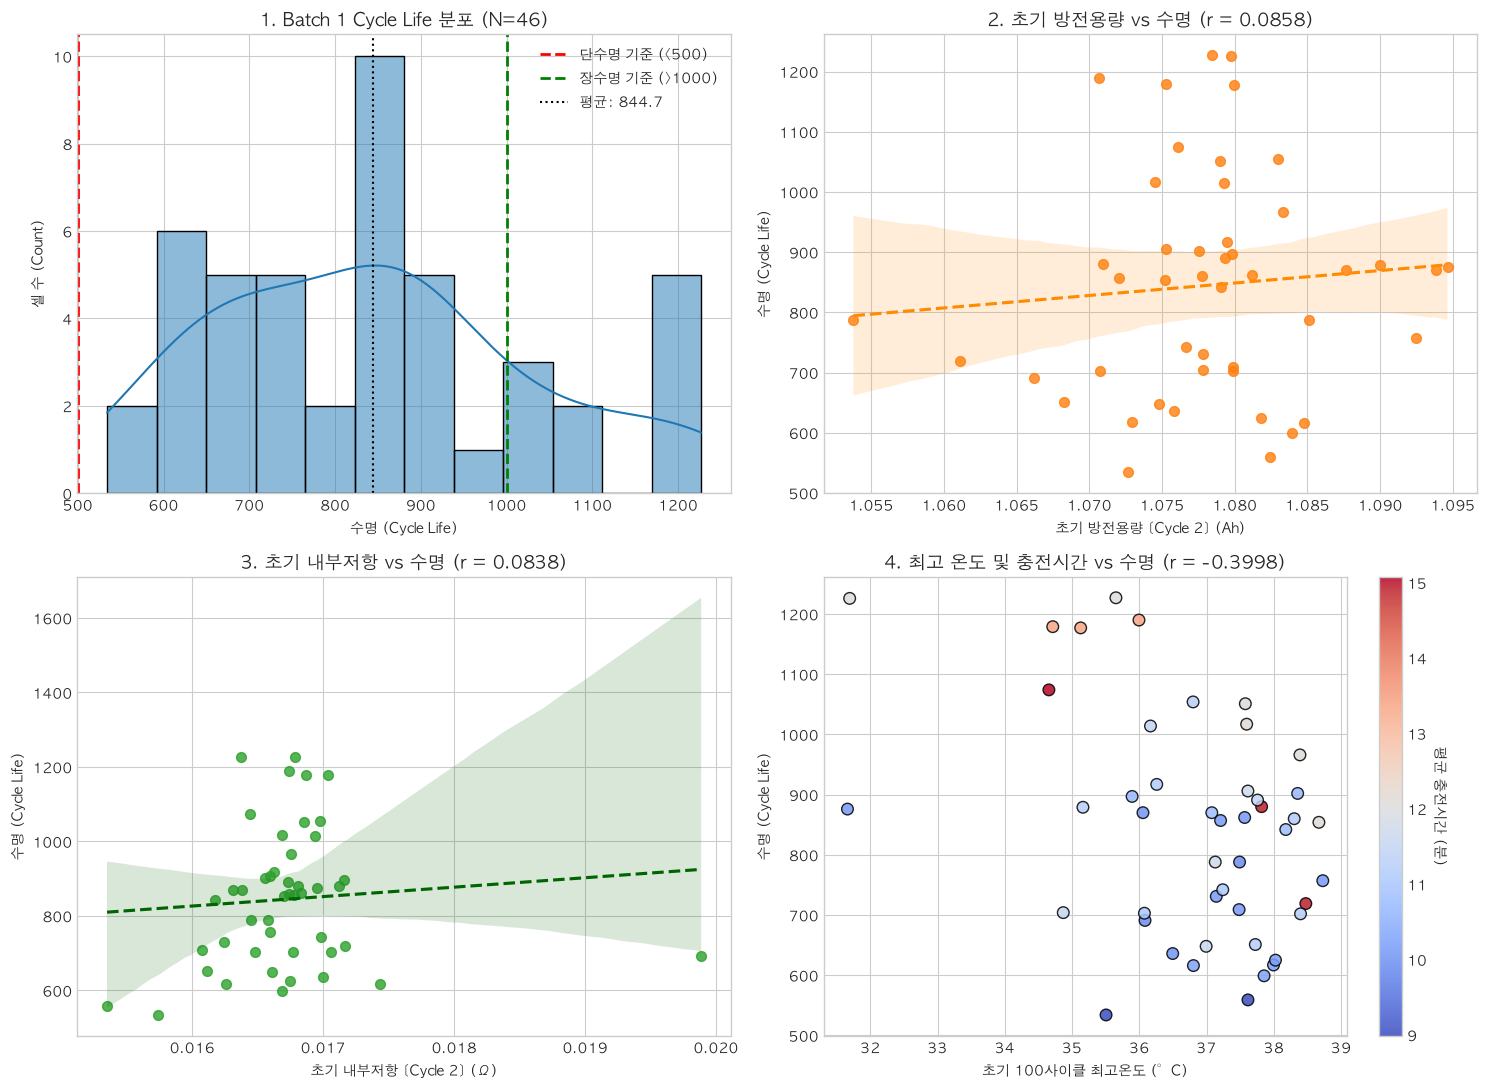

In [139]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# 1. 수명 분포 (Target Distribution)
sns.histplot(feat_b1['cycle_life'], kde=True, ax=axes[0, 0], color='#1f77b4', bins=12)
axes[0, 0].axvline(500, color='red', linestyle='--', linewidth=2, label='단수명 기준 (<500)')
axes[0, 0].axvline(1000, color='green', linestyle='--', linewidth=2, label='장수명 기준 (>1000)')
axes[0, 0].axvline(feat_b1['cycle_life'].mean(), color='black', linestyle=':', label=f'평균: {feat_b1["cycle_life"].mean():.1f}')
axes[0, 0].set_title('1. Batch 1 Cycle Life 분포 (N=46)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('수명 (Cycle Life)')
axes[0, 0].set_ylabel('셀 수 (Count)')
axes[0, 0].legend()

# 2. 초기 용량 vs 수명
r_q = feat_b1['q_init_c2'].corr(feat_b1['cycle_life'])
sns.regplot(x='q_init_c2', y='cycle_life', data=feat_b1, ax=axes[0, 1], color='#ff7f0e',
            scatter_kws={'alpha': 0.8, 's': 50}, line_kws={'color': 'darkorange', 'linestyle': '--'})
axes[0, 1].set_title(f'2. 초기 방전용량 vs 수명 (r = {r_q:.4f})', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('초기 방전용량 [Cycle 2] (Ah)')
axes[0, 1].set_ylabel('수명 (Cycle Life)')

# 3. 초기 내부저항 vs 수명
r_ir = feat_b1['ir_init'].corr(feat_b1['cycle_life'])
sns.regplot(x='ir_init', y='cycle_life', data=feat_b1, ax=axes[1, 0], color='#2ca02c',
            scatter_kws={'alpha': 0.8, 's': 50}, line_kws={'color': 'darkgreen', 'linestyle': '--'})
axes[1, 0].set_title(f'3. 초기 내부저항 vs 수명 (r = {r_ir:.4f})', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('초기 내부저항 [Cycle 2] (Ω)')
axes[1, 0].set_ylabel('수명 (Cycle Life)')

# 4. 최고 온도 & 평균 충전시간 vs 수명
r_t = feat_b1['t_max_100'].corr(feat_b1['cycle_life'])
scatter = axes[1, 1].scatter(feat_b1['t_max_100'], feat_b1['cycle_life'], 
                             c=feat_b1['ch_time_avg_min'], cmap='coolwarm', s=70, alpha=0.85, edgecolors='k')
cbar = plt.colorbar(scatter, ax=axes[1, 1])
cbar.set_label('평균 충전시간 (분)', rotation=270, labelpad=15)
axes[1, 1].set_title(f'4. 최고 온도 및 충전시간 vs 수명 (r = {r_t:.4f})', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('초기 100사이클 최고온도 (°C)')
axes[1, 1].set_ylabel('수명 (Cycle Life)')

plt.tight_layout()
plt.show()

### 💡 대시보드 시각화 핵심 관측 결과 및 시사점

1. **수명 분포의 분산 (질문 1)**:
   - Batch 1에서 500사이클 미만의 조기 단수명 셀은 0개이며, **800~900사이클 구간에 가장 밀집(중앙값 858.5사이클)**되어 있습니다.
   - 1,000사이클을 초과하는 장수명 셀(최대 1,227사이클)도 분포하여 동일 초기 스펙임에도 수명 산포가 큽니다.

2. **초기 스칼라 변수의 선형 상관성 관측**:
   - **초기 방전용량(`q_init_c2`)과 수명의 Pearson 상관계수: `r = 0.0858`**
   - **초기 내부저항(`ir_init`)과 수명의 Pearson 상관계수: `r = 0.0838`**
   - **관측 시사점**: 출하 시점의 단순 초기 용량이나 저항 크기는 수명과의 **선형적 상관성이 매우 약함**이 관측됩니다. (단, 비선형적 관계나 다변량 결합 효과는 배제하지 않으며, 추가 탐색이 필요합니다.)

3. **온도 스트레스 관측 (질문 4, 5)**:
   - **최고 온도(`t_max_100`)와 수명의 상관계수: `r = -0.3998`**
   - 초기 100사이클 동안 고온에 도달한 셀일수록 수명이 짧아지는 음의 선형 경향이 관측됩니다.

4. **후속 분석(열화 곡선 및 $\Delta Q(V)$) 연결**:
   - 단일 스칼라 지표만으로는 선형적 설명력이 제한적이므로, 사이클 진행에 따른 방전 용량 감쇠 추이(질문 2)와 전압별 용량 변화 곡선인 $\Delta Q_{100-10}(V)$(질문 3)을 분석하여 수명 예측을 위한 복합 물리 신호를 발굴해야 합니다.


## 5. Batch 2 라벨 결측 현황

Batch 2는 최종 평가용으로 유지한다. 여기서는 프로토콜별 셀 수와 **라벨 유무만** 확인하고, 수명 분포는 8장 Q1에서 기술적으로 비교한다. 라벨이 있는 39개 셀은 평가 후보이며, 최종 피처 계산 가능 여부는 별도로 검증한다.


In [140]:
b2_path = os.path.join(DATA_DIR, "2018-02-20_batchdata_updated_struct_errorcorrect.mat")
df_b2 = load_batch_summary(b2_path, "Batch2")

# Batch 2 정책별 셀 수 및 라벨 결측 현황 점검 (사후 유출 정보 배제)
b2_audit = df_b2.groupby("policy").agg(
    셀수=("cell_id", "count"),
    수명_결측수=("cycle_life", lambda s: s.isna().sum())
).reset_index()

print(f"Batch 2 전체 로드 셀 수: {len(df_b2)}개")
print(f"  - 정상 라벨 보유 셀: {df_b2['cycle_life'].notna().sum()}개")
print(f"  - 라벨 결측(NaN) 셀: {df_b2['cycle_life'].isna().sum()}개 (평가 제외 대상)")

display(b2_audit)


Batch 2 전체 로드 셀 수: 47개
  - 정상 라벨 보유 셀: 39개
  - 라벨 결측(NaN) 셀: 8개 (평가 제외 대상)


,policy,셀수,수명_결측수
0,3.6C(30%)-6C,2,0
1,3.6C(80%)-3.6C(SLOWCYCLE,1,1
2,3.6C(9%)-5C,2,0
3,3.6C(9%)-5C(SLOWCYCLE,1,1
4,4.65C(44%)-5C,2,0
5,4.65C(69%)-6C,2,0
6,4.8C(80%)-4.8C,5,0
7,4.8C(80%)-4.8C(SLOWCYCLE,1,1
8,4.8C(80%)-4.8C-newstructure,3,0
9,5.2C(50%)-4.25C,5,0


## 6. 라벨 결측 셀 분리와 셀 수 검증

5번 장의 Batch 2 라벨 결측 현황을 바탕으로 평가 대상에서 라벨이 없는 셀을 분리한다. 아래 표는 **분리 전후 셀 수와 라벨 결측 수**를 확인한다. 다른 변수의 정제나 분포·곡선 전후 비교까지 완료했다는 뜻은 아니다.

### 현재 처리 원칙
1. Batch 2에서 라벨이 없는 8개 셀은 평가 계산에서 제외하고 원본은 보존한다. 결측 원인은 아직 확인하지 않았다.
2. Batch 1의 IQR 검토 후보 13건은 오류로 확정되지 않아 원본을 유지한다. 충전시간 평균 피처는 Cycle 13 장시간 기록의 이유를 확인할 때까지 보류한다.
3. Batch 1의 초기 요약값은 Cycle 1의 0을 제외하고 Cycle 2를 기준으로 삼는다. Batch 2의 Cycle 1은 같은 0 패턴이 아니므로, 피처 구간의 비교 가능성을 별도로 확인한다.
4. `cycle_life`는 타깃, `n_cycles`는 실험 종료 후 정보다. 둘 다 모델 입력에서 제외한다.
5. 이번 Q1에서는 Batch 2 수명 분포를 기술적으로 비교한다. 그 결과로 모델·피처를 선택하거나 튜닝하지 않는다.


In [141]:
# 처리 기준 확인
criteria_path = os.path.join(project_root, "results", "preprocessing_criteria.csv")
df_criteria = pd.read_csv(criteria_path)
display(df_criteria)

# 라벨 유무에 따른 셀 분리와 전후 수 확인
import importlib
import src.preprocess as preprocess
preprocess = importlib.reload(preprocess)

clean_b1, excl_b1 = preprocess.filter_clean_cells(df_b1)
clean_b2, excl_b2 = preprocess.filter_clean_cells(df_b2)

before_after_comp = pd.DataFrame([
    {
        "배치": batch,
        "분리 전 셀 수": len(raw),
        "라벨 결측 셀 수": len(excluded),
        "라벨 보유 셀 수": len(clean),
        "분리 후 라벨 결측 수": int(clean["cycle_life"].isna().sum()),
    }
    for batch, raw, clean, excluded in [
        ("Batch 1", df_b1, clean_b1, excl_b1),
        ("Batch 2", df_b2, clean_b2, excl_b2),
    ]
])
assert len(clean_b1) == 46 and len(clean_b2) == 39
assert before_after_comp["분리 후 라벨 결측 수"].eq(0).all()
display(before_after_comp)


,항목,대상_셀,원인_유형,처리_판정,근거_및_영향
0,Batch 2 수명 라벨 결측 (8개 셀),"Batch2_c22, c23, c35, c36, c37, c38, c39, c40","원인 미확인; VarCharge 4개, SLOWCYCLE 4개에서 관측",최종 평가 계산에서 제외; 원본 보존,라벨이 없어 지도 평가 지표를 계산할 수 없음. 임의 보간하지 않음
1,Batch 2 최고온도 400°C (101개 사이클),"Batch2_c38, Cycle 1–101",원인 미확인; 비정상 센서 기록 후보,라벨 결측 셀 분리와 별도로 기록; 수정 기준 보류,해당 셀은 위 라벨 결측 8개에 포함됨. 장비 원인과 온도 보정값은 미검증
2,"Batch 1 IQR 경계 밖 관측 (11개 셀, 13건)","Batch1_c03, c05, c07, c11, c14, c15, c18, c20,...",원인 미확인; Cycle 13 장시간 충전 기록 포함,원본 유지; 평균 충전시간 피처 사용 보류,이웃 사이클과 대조했으나 IQR 경계 밖이라는 사실만으로 오류·정상 여부를 확정할 ...
3,Batch 1 Cycle 1 요약 필드 0,Batch 1 46개 셀,요약 필드 0 기록; 실험상 원인 미확인,Batch 1 초기 요약 피처 기준 Cycle 2,Batch 2 Cycle 1은 같은 0 패턴이 아니므로 두 배치의 구간 비교 가능성...
4,사후 정보 n_cycles,전체 셀,실험 종료 후 기록된 총 사이클 수,모델 입력에서 제외,초기 100사이클 시점에 알 수 없는 정보의 유입 방지


,배치,분리 전 셀 수,라벨 결측 셀 수,라벨 보유 셀 수,분리 후 라벨 결측 수
0,Batch 1,46,0,46,0
1,Batch 2,47,8,39,0


### 라벨 결측 처리 결과

- Batch 1은 46개 셀 모두 라벨을 보유한다. Batch 2는 47개 중 라벨 결측 8개를 평가 대상에서 분리했고, 라벨 보유 셀은 39개다.
- `results/clean_cells_manifest.csv`에는 셀별 포함 여부와 제외 사유를 기록한다. Batch 2의 개별 수명값은 최종 평가 전 자료에 표시하지 않는다.
- 현재 확인한 범위는 **라벨 유무와 셀 수**다. 초기 피처 계산 가능 여부, 센서 기록, 처리 전후 분포·곡선 및 동일 물리 셀 여부는 이어서 검증해야 한다.


## 7. 초기 입력 데이터 유효성 점검

라벨을 보유한 셀에 대해 Cycle 2–100이 실제 배열 위치와 맞는지, 필요한 측정값이 빠짐없이 기록됐는지 확인한다. Batch 2는 **통과 셀 수만** 보고한다. 이 점검은 값을 수정하거나 최종 피처를 선택하지 않는다.


In [142]:
from src.preprocess import extract_clean_features

summary_fields = ["QDischarge", "QCharge", "IR", "Tmin", "Tavg", "Tmax", "chargetime"]
audit_rows = []
for batch_name, clean_df in [("Batch 1", clean_b1), ("Batch 2", clean_b2)]:
    extracted = extract_clean_features(clean_df).set_index("cell_id")
    feature_names = [c for c in extracted.columns if c not in
                     {"batch", "policy", "cycle_life", "n_cycles"}]
    for _, cell in clean_df.iterrows():
        cycles = np.asarray(cell["cycles"])
        aligned = np.array_equal(cycles[1:100], np.arange(2, 101))
        lengths_ok = all(len(cell[field]) == len(cycles) for field in summary_fields)
        finite_raw = aligned and lengths_ok and all(
            np.isfinite(np.asarray(cell[field])[1:100]).all() for field in summary_fields
        )
        positive_charge = finite_raw and bool((np.asarray(cell["QCharge"])[1:100] > 0).all())
        finite_features = bool(np.isfinite(
            extracted.loc[cell["cell_id"], feature_names].to_numpy(dtype=float)
        ).all())
        audit_rows.append({
            "batch": batch_name,
            "cell_id": cell["cell_id"],
            "cycle_2_100_정렬": aligned,
            "배열_길이_일치": lengths_ok,
            "원본_유한값": finite_raw,
            "충전용량_양수": positive_charge,
            "후보_피처_유한값": finite_features,
            "입력_검증통과": aligned and lengths_ok and finite_raw and positive_charge and finite_features,
        })

early_input_audit = pd.DataFrame(audit_rows)
early_input_audit.to_csv(os.path.join(project_root, "results", "early_input_audit.csv"), index=False)
audit_summary = early_input_audit.groupby("batch", sort=False).agg(
    검사_셀수=("cell_id", "count"), 통과_셀수=("입력_검증통과", "sum")
)
display(audit_summary)
assert early_input_audit["입력_검증통과"].all(), "입력 검증 실패 셀을 확인하세요."


,검사_셀수,통과_셀수
batch,,
Batch 1,46,46
Batch 2,39,39


### 점검 결과

- Batch 1은 **46/46개**, Batch 2의 라벨 보유 셀은 **39/39개**가 Cycle 2–100 정렬·측정 배열·유한값·양의 충전용량·17개 후보 피처 계산 점검을 통과했다.
- 이 결과는 **계산 가능성** 확인이다. 두 배치의 Cycle 1 기록 방식 차이, 실제 동일 물리 셀 여부, 충전시간 Cycle 13의 이유, 값의 물리적 신뢰성은 별도 검증이 필요하다. Batch 2의 타깃 분포나 피처값은 이 단계에서 사용하지 않았다.


## 8. Q1 Batch 1·2·3 Cycle Life 분포

세 배치의 수명 분포를 같은 축에서 비교한다. 라벨이 없는 셀은 수명 통계에서 제외하고 결측 수를 함께 보고한다. Batch 2 라벨 분포는 이번 Q1에서 확인하지만, 이 결과로 모델·피처를 선택하거나 튜닝하지 않는다.


,배치,전체 셀,라벨 보유,라벨 결측,평균,중앙값,표준편차,최솟값,Q1,Q3,최댓값,500 미만,500 미만 비율(%),1000 초과,1000 초과 비율(%)
0,Batch 1,46,46,0,844.7,858.5,184.6,534.000000,703.250000,914.250000,1227.000000,0,0.0,10,21.7
1,Batch 2,47,39,8,565.7,472.0,222.2,392.000000,439.500000,508.500000,1186.000000,28,71.8,3,7.7
2,Batch 3,46,44,2,1059.7,1005.5,313.9,541.000000,828.000000,1155.250000,1935.000000,0,0.0,23,52.3


,배치,셀 ID,수명,IQR 하한,IQR 상한
0,Batch 2,Batch2_c07,777.0000,336.0000,612.0000
1,Batch 2,Batch2_c08,904.0000,336.0000,612.0000
2,Batch 2,Batch2_c09,791.0000,336.0000,612.0000
3,Batch 2,Batch2_c32,809.0000,336.0000,612.0000
4,Batch 2,Batch2_c33,1140.0000,336.0000,612.0000
5,Batch 2,Batch2_c34,1186.0000,336.0000,612.0000
6,Batch 2,Batch2_c43,1029.0000,336.0000,612.0000
7,Batch 2,Batch2_c44,841.0000,336.0000,612.0000
8,Batch 2,Batch2_c45,997.0000,336.0000,612.0000
9,Batch 3,Batch3_c07,1836.0000,337.1250,1646.1250


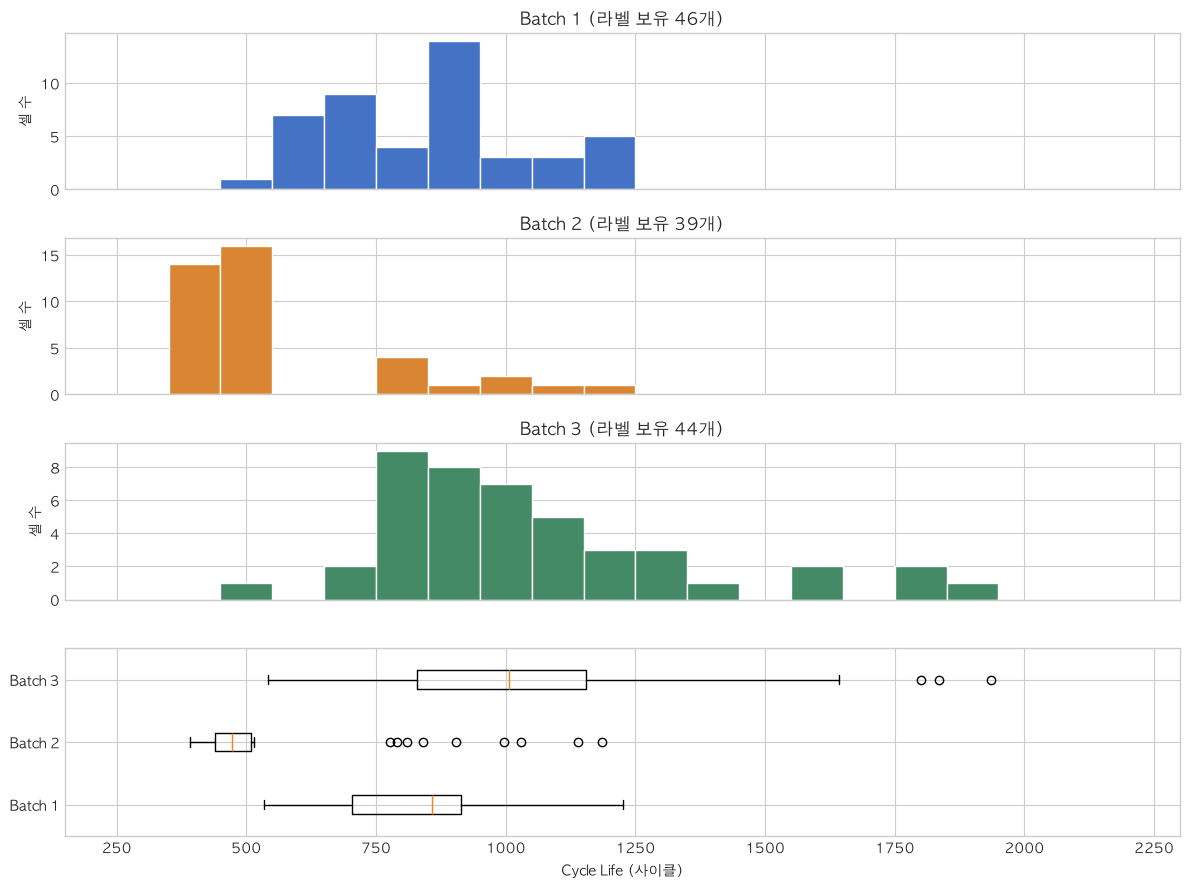

In [143]:
b3_path = os.path.join(DATA_DIR, "2018-04-12_batchdata_updated_struct_errorcorrect.mat")
df_b3 = load_batch_summary(b3_path, "Batch3")
q1_batches = [("Batch 1", df_b1), ("Batch 2", df_b2), ("Batch 3", df_b3)]
q1_rows, q1_outliers = [], []
for name, df in q1_batches:
    life = df["cycle_life"].dropna()
    q1, q3 = life.quantile([0.25, 0.75])
    lower, upper = q1 - 1.5 * (q3 - q1), q3 + 1.5 * (q3 - q1)
    q1_rows.append({
        "배치": name, "전체 셀": len(df), "라벨 보유": len(life), "라벨 결측": len(df) - len(life),
        "평균": life.mean(), "중앙값": life.median(), "표준편차": life.std(),
        "최솟값": life.min(), "Q1": q1, "Q3": q3, "최댓값": life.max(),
        "500 미만": int((life < 500).sum()), "500 미만 비율(%)": (life < 500).mean() * 100,
        "1000 초과": int((life > 1000).sum()), "1000 초과 비율(%)": (life > 1000).mean() * 100,
    })
    flagged = df.loc[(df["cycle_life"] < lower) | (df["cycle_life"] > upper)]
    for _, row in flagged.iterrows():
        q1_outliers.append({"배치": name, "셀 ID": row["cell_id"],
                            "수명": row["cycle_life"], "IQR 하한": lower, "IQR 상한": upper})

q1_summary = pd.DataFrame(q1_rows)
q1_outlier_candidates = pd.DataFrame(q1_outliers)
q1_outlier_candidates.to_csv(os.path.join(project_root, "results", "q1_cycle_life_outlier_candidates.csv"), index=False)
display(q1_summary.style.format({
    "평균": "{:.1f}", "중앙값": "{:.1f}", "표준편차": "{:.1f}",
    "500 미만 비율(%)": "{:.1f}", "1000 초과 비율(%)": "{:.1f}"
}))
display(q1_outlier_candidates)

bins = np.arange(150, 2351, 100)
fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True,
                         gridspec_kw={"height_ratios": [1, 1, 1, 1.2]})
colors = ["#4472c4", "#d98531", "#458a67"]
for ax, (name, df), color in zip(axes[:3], q1_batches, colors):
    life = df["cycle_life"].dropna()
    ax.hist(life, bins=bins, color=color, edgecolor="white")
    ax.set(ylabel="셀 수", title=f"{name} (라벨 보유 {len(life)}개)")
axes[3].boxplot([df["cycle_life"].dropna() for _, df in q1_batches],
                orientation="horizontal", tick_labels=[name for name, _ in q1_batches])
axes[3].set(xlabel="Cycle Life (사이클)", xlim=(150, 2300))
fig.tight_layout()
fig.savefig(os.path.join(project_root, "results", "q1_cycle_life_distribution.png"), dpi=160)
plt.show()


### Q1 관측과 생각

- 라벨 보유 셀 기준 중앙값은 Batch 1 **858.5**, Batch 2 **472.0**, Batch 3 **1,005.5사이클**이다. Batch 2는 짧은 쪽에, Batch 3는 긴 쪽에 더 많이 분포한다.
- 500사이클 미만은 Batch 1 **0/46**, Batch 2 **28/39(71.8%)**, Batch 3 **0/44**다. 1,000사이클 초과는 순서대로 **10/46(21.7%)**, **3/39(7.7%)**, **23/44(52.3%)**다. 세 배치를 한 기준의 분류 데이터로 합치면 배치 차이가 라벨과 강하게 엮일 수 있다.
- 수명 라벨 결측은 Batch 1 **0개**, Batch 2 **8개**, Batch 3 **2개**다. 결측 원인이나 낮은 수명의 물리적 원인은 이 그래프만으로 확정할 수 없다.
- IQR 경계 밖 수명은 Batch 1 **0개**, Batch 2 **9개**, Batch 3 **3개**다. 통계적 검토 후보이며 삭제 대상이라는 뜻은 아니다. 가장 짧은 셀과 충전 조건의 관계는 Q4에서 확인한다.
- 이 관측은 가이드의 “Batch 1·2 수명 분포 유사” 설명과 맞지 않는다. 현재 `.mat` 파일 기준 결과로 보고하고, 데이터 버전·셀 매핑 차이는 별도로 확인한다. Batch 2의 Q1 기술통계는 이후 모델·피처 선택에 사용하지 않는다.


In [144]:
# Batch 2의 짧은 수명을 설명할 단서를 정책명과 기록 방식에서 확인
q1_b2 = df_b2.dropna(subset=["cycle_life"]).copy()
q1_b2["newstructure"] = q1_b2["policy"].str.contains("newstructure", regex=False)
q1_b2["기본 정책"] = q1_b2["policy"].str.replace("-newstructure", "", regex=False)
display(q1_b2.groupby("newstructure")["cycle_life"].agg(["count", "median", "min", "max"]))
display(q1_b2.groupby(["기본 정책", "newstructure"])["cycle_life"].agg(["count", "median"]))
q1_b2["추가 기록 사이클"] = q1_b2.apply(
    lambda r: int(r["cycles"][-1] - r["cycle_life"]), axis=1
)
display(q1_b2.groupby("newstructure")["추가 기록 사이클"].agg(["min", "median", "max"]))


,count,median,min,max
newstructure,,,,
False,30,451.0000,392.0000,514.0000
True,9,904.0000,777.0000,1186.0000


count   median
기본 정책           newstructure                
3.6C(30%)-6C    False             2 421.0000
3.6C(9%)-5C     False             2 394.5000
4.65C(44%)-5C   False             2 482.5000
4.65C(69%)-6C   False             2 452.0000
4.8C(80%)-4.8C  False             5 492.0000
                True              3 809.0000
5.2C(50%)-4.25C False             5 449.0000
5.2C(58%)-4C    False             4 483.0000
                True              3 904.0000
5.6C(26%)-4.5C  False             6 446.0000
                True              3 997.0000
6C(60%)-3C      False             2 400.0000

,min,median,max
newstructure,,,
False,15,19.5000,35
True,25,32.0000,66


### Batch 2가 유독 짧은 이유를 묻는 추가 점검

- Batch 2 라벨 보유 39셀 중 일반 정책 30셀의 수명은 **392–514사이클(중앙값 451)**, `newstructure` 표기 9셀은 **777–1,186사이클(중앙값 904)**이다. 일반 정책 셀이 짧은 쪽에 모인다는 사실은 확인된다. `newstructure`가 구체적으로 어떤 실험 차이인지는 정책명만으로 알 수 없다.
- 같은 기본 정책에서도 차이가 반복된다. `4.8C(80%)-4.8C`: 일반 **492** vs `newstructure` **809**, `5.2C(58%)-4C`: **483** vs **904**, `5.6C(26%)-4.5C`: **446** vs **997사이클**(각 중앙값). 따라서 정책 숫자만 같다고 실험 조건이 동일했다고 볼 수 없다.
- Batch 2는 수명 라벨 시점 이후에도 **15–66사이클** 기록이 이어진다. 반면 Batch 1·3은 기록 마지막 사이클이 수명 라벨보다 1 작다. Batch 2의 수명 라벨 근처 방전용량 중앙값은 약 **0.879 Ah**로 EOL 약 0.88 Ah와 맞아, 단순히 400–500에서 기록이 끊겨 수명이 짧게 보인다는 설명은 지지되지 않는다.
- 초기 Cycle 2 방전용량 중앙값은 Batch 2 일반 정책 **1.096 Ah**, `newstructure` **1.091 Ah**로 큰 차이를 보이지 않는다. 초기 값 하나로 수명 격차를 설명할 수 없다. 충전 구조·셀 구성·시험 시기·라벨 정의의 차이는 원자료 설명 및 Q2~Q4로 확인한다. **Batch 2 셀은 제외하지 않는다.**


## 9. Q2 방전용량 열화 곡선과 0.95 Ah 도달 시점

- **질문**: 방전용량은 초기 100사이클과 이후에 어떻게 변하는가?
- **범위**: Batch 1 라벨 보유 46셀의 Cycle 2 이후 요약 데이터. 0.95 Ah 첫 도달 시점은 편의상 정한 용량 기준이며, 곡선의 변곡점(Knee-point)을 탐지한 값은 아니다.


,Q2 평균 (Ah),Q100 평균 (Ah),초기 용량변화 (Q100-Q2) (mAh),초기 용량증가 셀 비율 (%),초기 평균 용량변화 기울기 (mAh/cycle),관측 기록 전체 평균 기울기 (mAh/cycle),0.95Ah 도달 셀 수,0.95Ah 미도달 셀 수,0.95Ah 첫 도달 사이클 평균,도달 후 수명 라벨까지 평균 사이클,도달 후 비율 (%)
0,1.08,1.08,2.60,91.30,0.03,-0.22,38.00,8.00,722.74,71.53,9.01


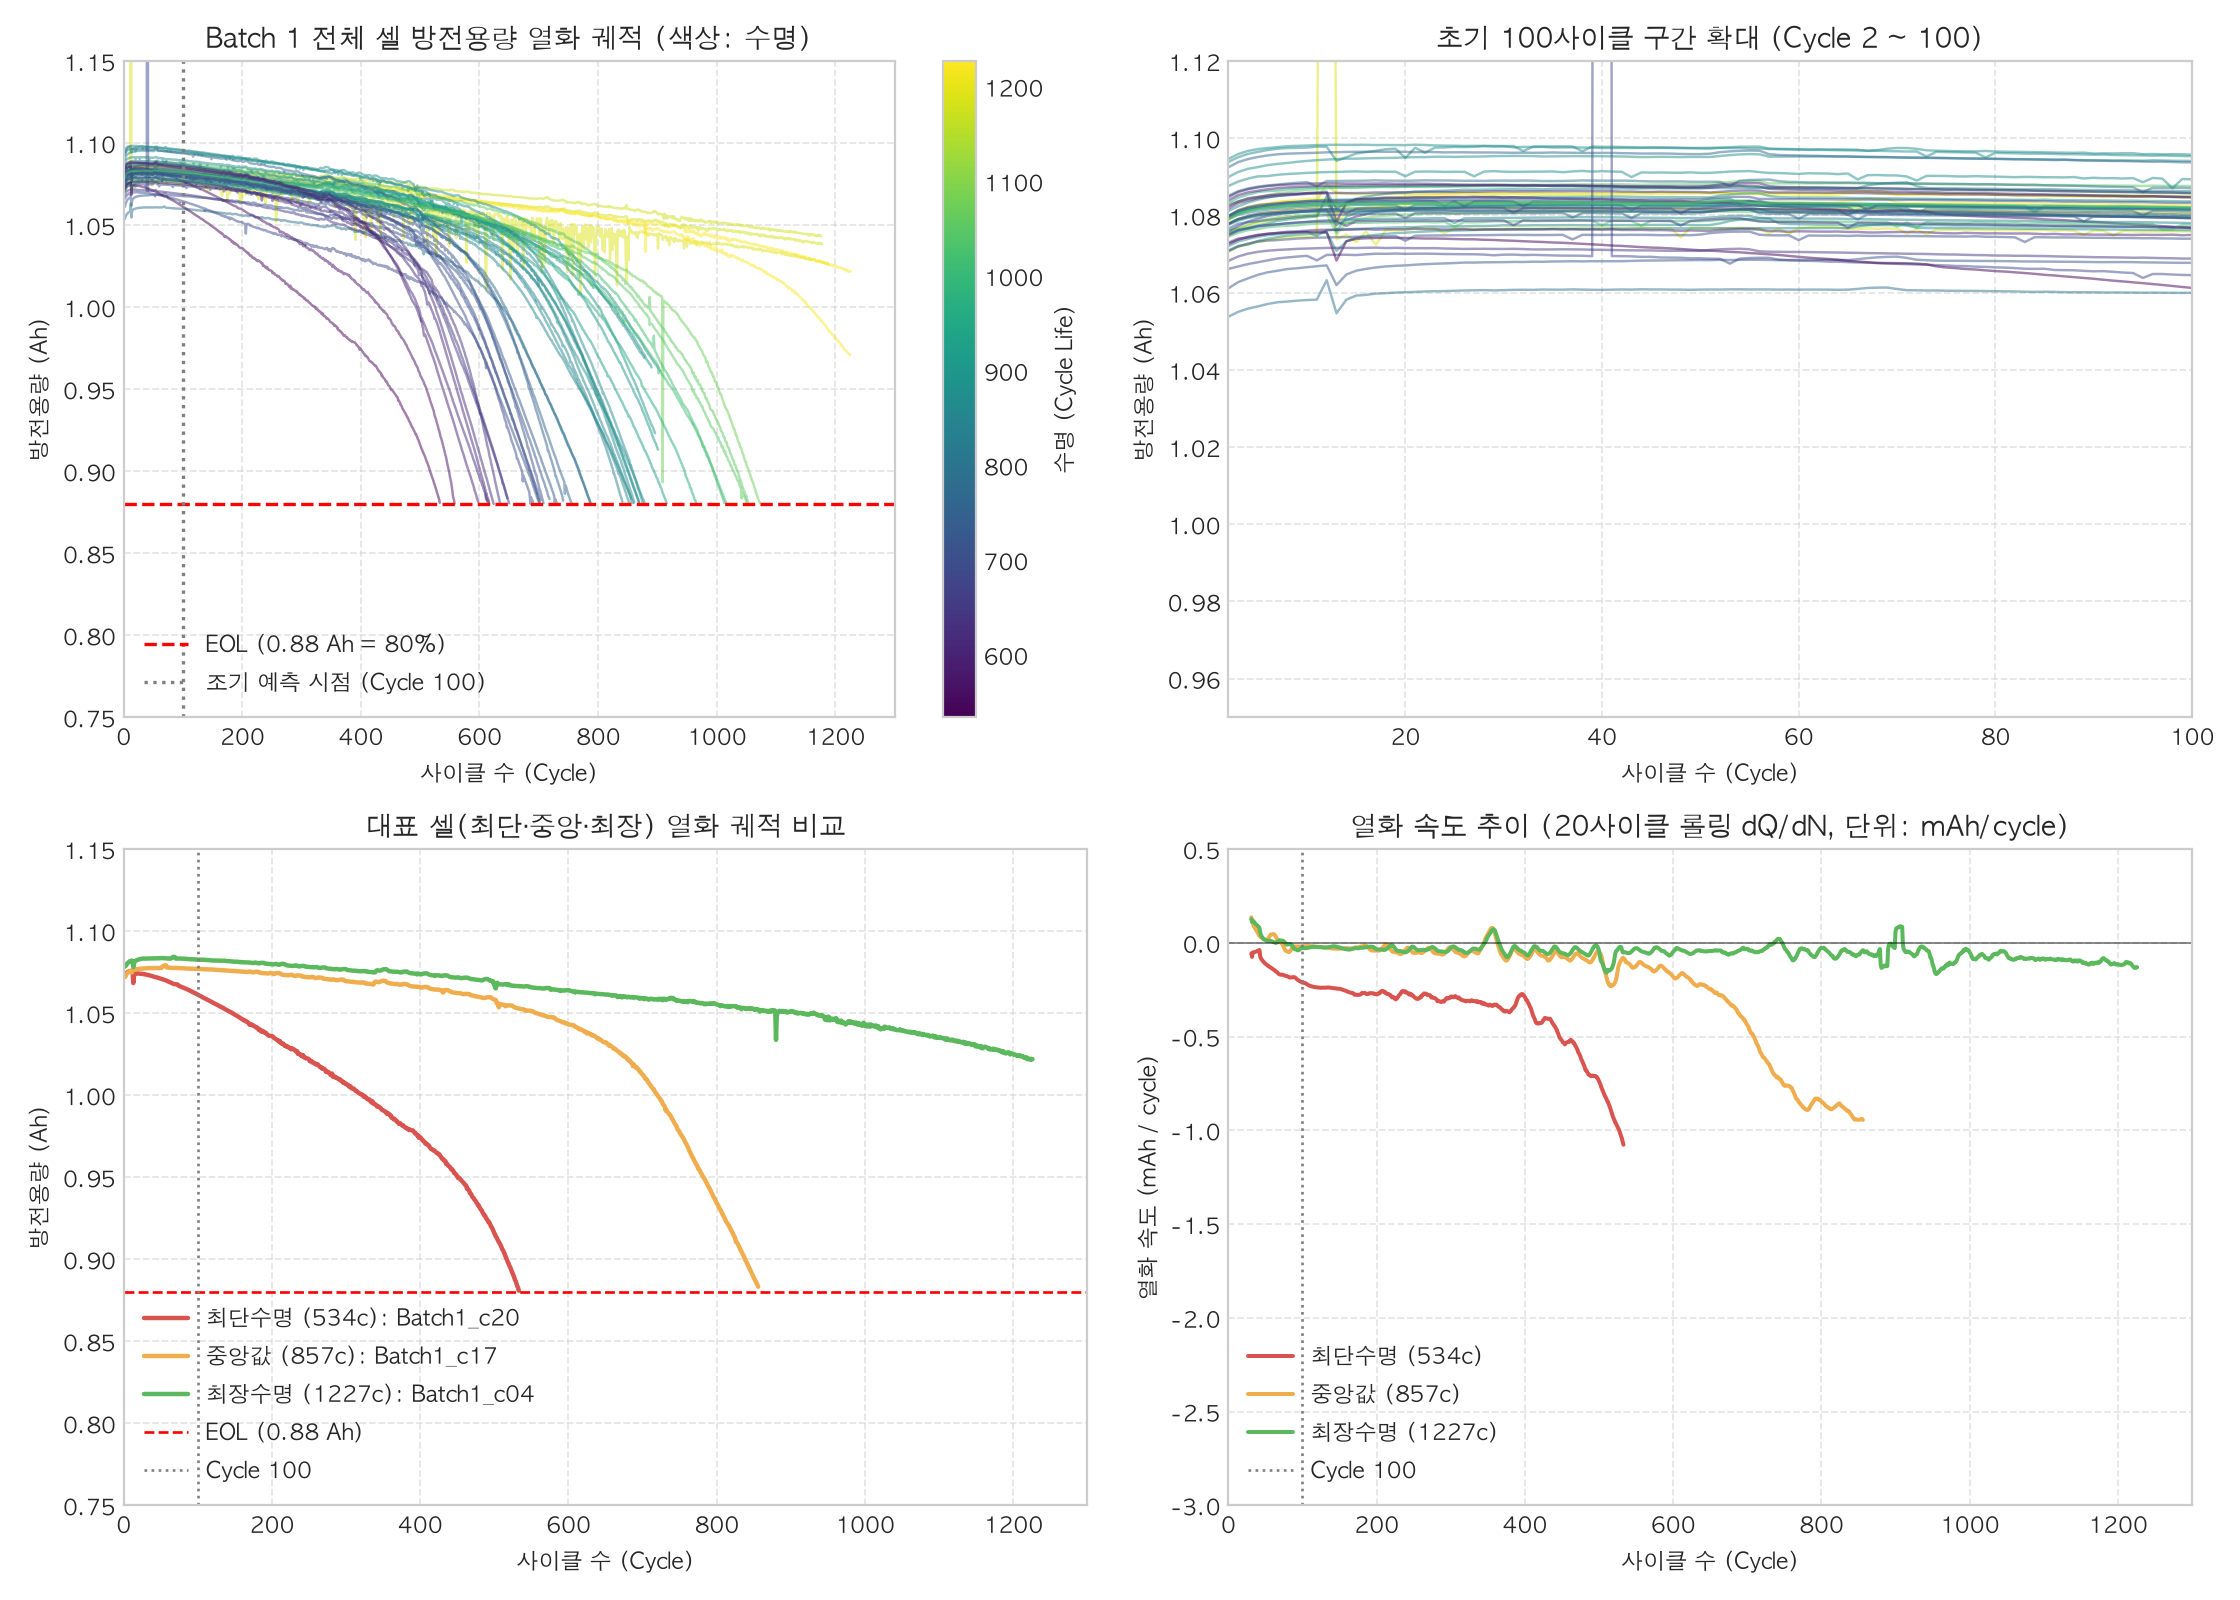

In [1]:
# 1. 초기 100사이클 vs 전체 수명 열화 통계 집계
q2_vals = [r["QDischarge"][1] for _, r in df_b1.iterrows()]
q100_vals = [r["QDischarge"][99] for _, r in df_b1.iterrows()]
delta_q100_2 = np.array(q100_vals) - np.array(q2_vals)

# 0.95 Ah는 변곡점 탐지가 아닌 임의의 용량 도달 기준이다.
threshold_cycles = []
for _, r in df_b1.iterrows():
    qd = r["QDischarge"][1:]
    hits = np.flatnonzero(qd <= 0.95)
    threshold_cycles.append(float(r["cycles"][hits[0] + 1]) if len(hits) else np.nan)

threshold_cycles = np.array(threshold_cycles)
reached = np.isfinite(threshold_cycles)
cycles_after_threshold = df_b1["cycle_life"].to_numpy()[reached] - threshold_cycles[reached]

q2_stat_df = pd.DataFrame([{
    "Q2 평균 (Ah)": np.mean(q2_vals),
    "Q100 평균 (Ah)": np.mean(q100_vals),
    "초기 용량변화 (Q100-Q2) (mAh)": np.mean(delta_q100_2) * 1000,
    "초기 용량증가 셀 비율 (%)": (delta_q100_2 >= 0).mean() * 100,
    "초기 평균 용량변화 기울기 (mAh/cycle)": (np.mean(delta_q100_2) / 98) * 1000,
    "관측 기록 전체 평균 기울기 (mAh/cycle)": np.mean([(r["QDischarge"][-1] - r["QDischarge"][1]) / (r["cycles"][-1] - r["cycles"][1]) * 1000 for _, r in df_b1.iterrows()]),
    "0.95Ah 도달 셀 수": int(reached.sum()),
    "0.95Ah 미도달 셀 수": int((~reached).sum()),
    "0.95Ah 첫 도달 사이클 평균": np.nanmean(threshold_cycles),
    "도달 후 수명 라벨까지 평균 사이클": np.mean(cycles_after_threshold),
    "도달 후 비율 (%)": np.mean(cycles_after_threshold) / df_b1["cycle_life"].to_numpy()[reached].mean() * 100
}])
display(q2_stat_df.style.format("{:.2f}"))

# 2. 2x2 열화 곡선·용량 기준·기울기 시각화 (knee 탐지 아님)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
eol_val = 0.88

# (1) 전체 셀 열화 곡선
ax1 = axes[0, 0]
cmap = plt.get_cmap("viridis")
norm = plt.Normalize(df_b1["cycle_life"].min(), df_b1["cycle_life"].max())

for _, r in df_b1.iterrows():
    qd = r["QDischarge"][1:]
    cycles = np.arange(2, len(qd) + 2)
    color = cmap(norm(r["cycle_life"]))
    ax1.plot(cycles, qd, color=color, alpha=0.5, linewidth=1.1)

ax1.axhline(eol_val, color="red", linestyle="--", linewidth=1.5, label="EOL (0.88 Ah = 80%)")
ax1.axvline(100, color="gray", linestyle=":", linewidth=1.5, label="조기 예측 시점 (Cycle 100)")
ax1.set_title("Batch 1 전체 셀 방전용량 열화 궤적 (색상: 수명)")
ax1.set_xlabel("사이클 수 (Cycle)")
ax1.set_ylabel("방전용량 (Ah)")
ax1.set_xlim(0, 1300)
ax1.set_ylim(0.75, 1.15)
ax1.grid(True, linestyle="--", alpha=0.5)
ax1.legend(loc="lower left")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax1)
cbar.set_label("수명 (Cycle Life)")

# (2) 초기 100사이클 확대
ax2 = axes[0, 1]
for _, r in df_b1.iterrows():
    qd = r["QDischarge"][1:100]
    cycles = np.arange(2, len(qd) + 2)
    color = cmap(norm(r["cycle_life"]))
    ax2.plot(cycles, qd, color=color, alpha=0.5, linewidth=1.1)

ax2.set_title("초기 100사이클 구간 확대 (Cycle 2 ~ 100)")
ax2.set_xlabel("사이클 수 (Cycle)")
ax2.set_ylabel("방전용량 (Ah)")
ax2.set_xlim(2, 100)
ax2.set_ylim(0.95, 1.12)
ax2.grid(True, linestyle="--", alpha=0.5)

# (3) 대표 셀 열화 비교
ax3 = axes[1, 0]
min_cell = df_b1.loc[df_b1["cycle_life"].idxmin()]
med_idx = (df_b1["cycle_life"] - df_b1["cycle_life"].median()).abs().idxmin()
med_cell = df_b1.loc[med_idx]
max_cell = df_b1.loc[df_b1["cycle_life"].idxmax()]

rep_cells = [
    (f"최단수명 ({min_cell['cycle_life']:.0f}c)", min_cell, "#d9534f"),
    (f"중앙값 ({med_cell['cycle_life']:.0f}c)", med_cell, "#f0ad4e"),
    (f"최장수명 ({max_cell['cycle_life']:.0f}c)", max_cell, "#5cb85c")
]

for label, cell, col in rep_cells:
    qd = cell["QDischarge"][1:]
    cycles = np.arange(2, len(qd) + 2)
    ax3.plot(cycles, qd, color=col, linewidth=2.0, label=f"{label}: {cell['cell_id']}")

ax3.axhline(eol_val, color="red", linestyle="--", linewidth=1.2, label="EOL (0.88 Ah)")
ax3.axvline(100, color="gray", linestyle=":", linewidth=1.2, label="Cycle 100")
ax3.set_title("대표 셀(최단·중앙·최장) 열화 궤적 비교")
ax3.set_xlabel("사이클 수 (Cycle)")
ax3.set_ylabel("방전용량 (Ah)")
ax3.set_xlim(0, 1300)
ax3.set_ylim(0.75, 1.15)
ax3.grid(True, linestyle="--", alpha=0.5)
ax3.legend(loc="lower left")

# (4) 열화 가속도 (20사이클 롤링 기울기 dQ/dN)
ax4 = axes[1, 1]
for label, cell, col in rep_cells:
    qd = pd.Series(cell["QDischarge"][1:])
    rolling_slope = (qd.diff(20) / 20).rolling(10).mean() * 1000
    cycles = np.arange(2, len(qd) + 2)
    ax4.plot(cycles, rolling_slope, color=col, linewidth=1.8, label=label)

ax4.axhline(0, color="black", linestyle="-", linewidth=0.8, alpha=0.5)
ax4.axvline(100, color="gray", linestyle=":", linewidth=1.2, label="Cycle 100")
ax4.set_title("열화 속도 추이 (20사이클 롤링 dQ/dN, 단위: mAh/cycle)")
ax4.set_xlabel("사이클 수 (Cycle)")
ax4.set_ylabel("열화 속도 (mAh / cycle)")
ax4.set_xlim(0, 1300)
ax4.set_ylim(-3.0, 0.5)
ax4.grid(True, linestyle="--", alpha=0.5)
ax4.legend(loc="lower left")

fig.tight_layout()
fig_path = os.path.join(project_root, "results", "q2_discharge_capacity_degradation.png")
fig.savefig(fig_path, dpi=160)
plt.show()


### Q2 관측과 해석

- Batch 1의 Cycle 2 방전용량 평균은 **1.0781 Ah**, Cycle 100은 **1.0807 Ah**다. **42/46셀**에서 증가했고 평균 변화는 **+2.60 mAh**다. 초기 98사이클의 평균 기울기 **+0.027 mAh/cycle**를 전체 수명까지 직선으로 연장하는 방식은 적절하지 않다.
- 0.95 Ah를 실제 측정에서 지난 셀은 **38/46개**다. 이 38개의 첫 도달 사이클 평균은 **722.7**, 수명 라벨까지 남은 사이클 평균은 **71.5**(해당 38셀 평균 수명의 **9.0%**)다. **8셀은 기록된 구간에서 0.95 Ah에 도달하지 않았다.** 종전 평균 785.6·59.1은 이 8셀의 수명 라벨을 임의로 도달 시점으로 넣어 계산한 값이어서 철회한다.
- 일부 열화 궤적과 대표 셀의 후기 기울기는 더 가팔라진다. 그러나 **0.95 Ah는 변곡점이 아니며, 모든 셀에서 2단계 열화나 급격한 종말을 입증한 것은 아니다.** 8셀의 마지막 방전용량은 0.95 Ah보다 높아 수명 라벨과 EOL 0.88 Ah 측정값의 대응도 추가 확인이 필요하다.
- 초기 용량 곡선이 겹쳐 보여도 수명 예측력이 없다고 단정할 수 없다. 초기 용량·변화량과 수명의 관계는 별도 통계 및 Batch 1 검증에서 평가한다. 전압별 용량 변화와 저항도 후보로 검토하되 아직 채택하지 않는다.


### Q2 보강: 세 배치의 초기 변화와 기록 말기 기울기

동일 기준으로 라벨 보유 Batch1 46·Batch2 39·Batch3 44셀을 비교한다. 공식 후속 자료는 사용하지 않는다. 실제 사이클 번호로 Cycle2·100을 선택하고 유한한 측정값만 사용한다. 전체 기록 곡선과 초기 구간을 같은 축으로 그린다. 배치별 평균 곡선은 후기까지 남는 셀이 달라질 때 생존 집단 구성이 변할 수 있어 모든 개별 곡선을 표시한다.

기울기는 Cycle100~200과 **각 셀의 기록 마지막100사이클 구간**에서 직선 적합으로 계산한다. 후자는 모든 셀의 같은 절대 사이클이나 EOL 구간을 뜻하지 않는다. 0.95Ah 첫 도달은 보조 기준이며 미도달 셀은 그대로 결측으로 남긴다. 아래 분석은 EDA이고 Cycle100 이후 정보를 모델 피처에 추가하지 않는다.


,batch,cells,q2_mean_Ah,q100_mean_Ah,delta_mean_mAh,increased_cells,reached_095_cells,median_095_cycle,median_095_sustained5_cycle,middle_slope_median,end_slope_median,steeper_cells
0,Batch1,46,1.0781,1.0807,2.5996,42,38,708.0,708.0,-0.0396,-0.9030,46
1,Batch2,39,1.0935,1.0956,2.1127,25,39,432.0,437.0,-0.0061,-1.8915,39
2,Batch3,44,1.0636,1.0639,0.2493,37,44,944.0,944.0,-0.0364,-0.9117,44


,group,cells,delta_mean_mAh,median_095_cycle,end_slope_median
0,general,30,2.8052,425.0,-1.9220
1,newstructure,9,-0.1959,797.0,-1.3036


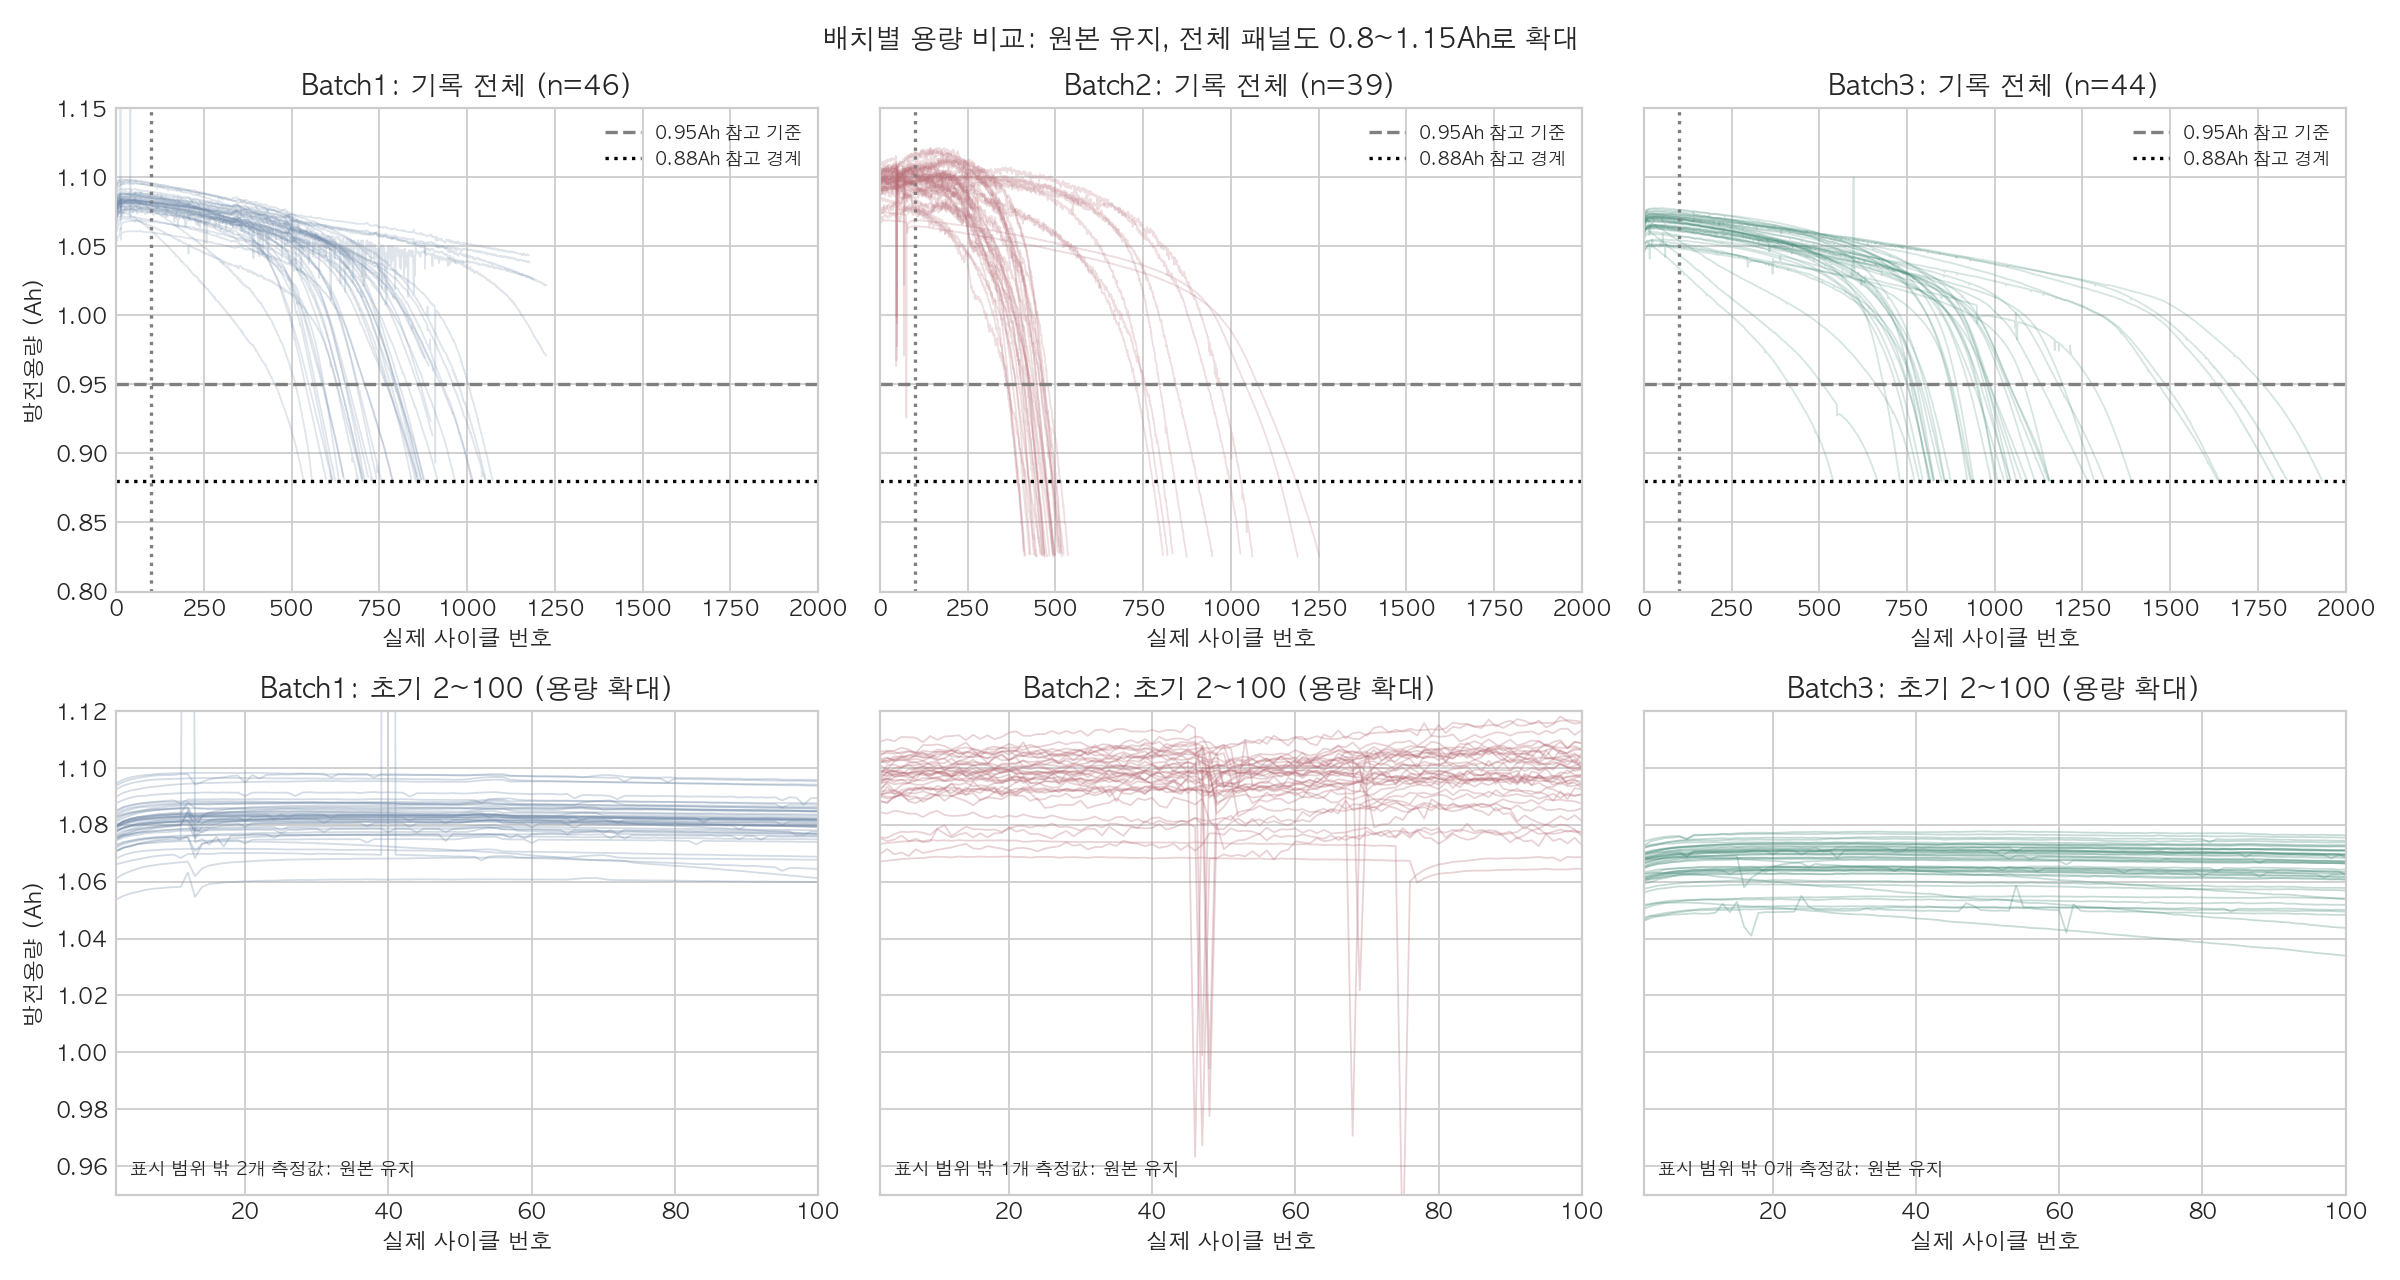

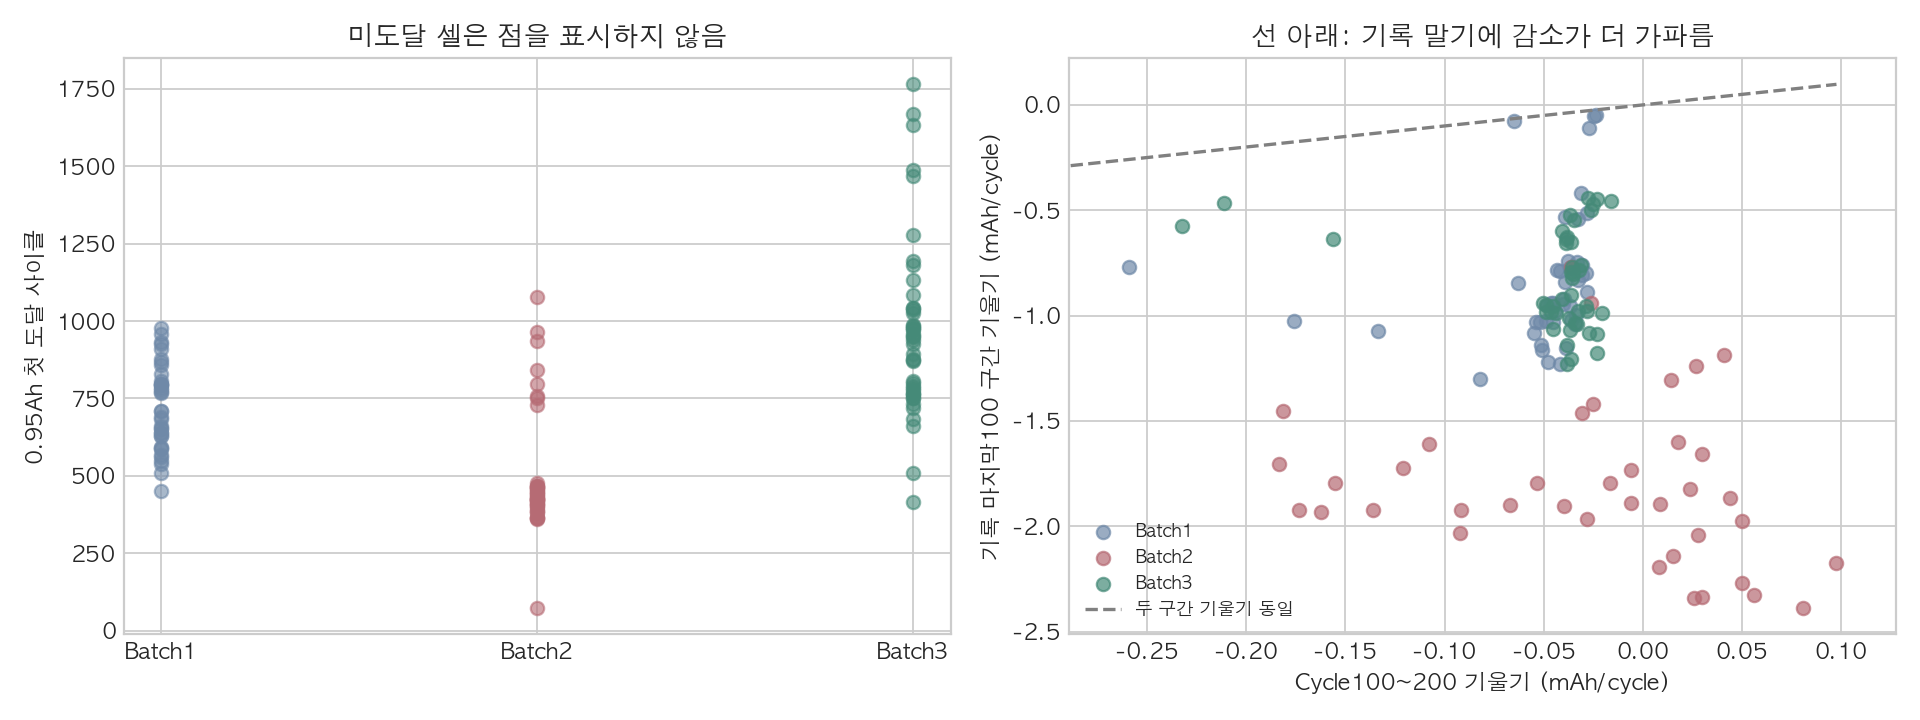

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
from src.preprocess import load_batch_summary

ROOT = Path(project_root)
Q2_OUT = ROOT / "results/q2"
Q2_OUT.mkdir(exist_ok=True)
q2_files = {
    "Batch1": "2017-05-12_batchdata_updated_struct_errorcorrect.mat",
    "Batch2": "2018-02-20_batchdata_updated_struct_errorcorrect.mat",
    "Batch3": "2018-04-12_batchdata_updated_struct_errorcorrect.mat",
}
q2_curves, q2_rows = {}, []
for batch_name, filename in q2_files.items():
    for _, row in load_batch_summary(ROOT / "data" / filename, batch_name).iterrows():
        if not (np.isfinite(row.cycle_life) and row.cycle_life > 0):
            continue
        cycles, capacity = row.cycles, row.QDischarge
        assert cycles.shape == capacity.shape
        positions = [np.flatnonzero(cycles == c) for c in (2, 100)]
        assert all(len(p) == 1 for p in positions)
        usable = (cycles >= 2) & np.isfinite(capacity)
        c, q = cycles[usable], capacity[usable]
        assert np.isfinite(c).all() and np.all(np.diff(c) > 0)

        def measured_slope(start, end):
            mask = (c >= start) & (c <= end)
            assert mask.sum() >= 20
            return float(np.polyfit(c[mask], q[mask], 1)[0] * 1000)

        hits = c[q <= 0.95]
        sustained = np.flatnonzero(np.convolve((q <= 0.95).astype(int), np.ones(5), mode="valid") == 5)
        sustained = [j for j in sustained if c[j + 4] - c[j] == 4]
        q2, q100 = capacity[positions[0][0]], capacity[positions[1][0]]
        q2_rows.append({
            "batch": batch_name, "cell_id": row.cell_id, "policy": row.policy,
            "group": "newstructure" if "newstructure" in row.policy else "general",
            "cycle_life": row.cycle_life, "q2_Ah": q2, "q100_Ah": q100,
            "delta_100_2_mAh": (q100 - q2) * 1000,
            "slope_100_200_mAh_cycle": measured_slope(100, 200),
            "slope_last100_mAh_cycle": measured_slope(c[-1] - 99, c[-1]),
            "last_record_cycle": c[-1],
            "first_095_cycle": hits[0] if len(hits) else np.nan,
            "first_095_sustained5_cycle": c[sustained[0]] if len(sustained) else np.nan,
        })
        q2_curves[row.cell_id] = (c, q)

q2_cells = pd.DataFrame(q2_rows)
assert q2_cells.cell_id.is_unique and len(q2_cells) == 129
q2_cells["steeper_at_end"] = q2_cells.slope_last100_mAh_cycle < q2_cells.slope_100_200_mAh_cycle
q2_summary = q2_cells.groupby("batch").agg(
    cells=("cell_id", "size"), q2_mean_Ah=("q2_Ah", "mean"),
    q100_mean_Ah=("q100_Ah", "mean"), delta_mean_mAh=("delta_100_2_mAh", "mean"),
    increased_cells=("delta_100_2_mAh", lambda x: int((x > 0).sum())),
    reached_095_cells=("first_095_cycle", "count"), median_095_cycle=("first_095_cycle", "median"),
    median_095_sustained5_cycle=("first_095_sustained5_cycle", "median"),
    middle_slope_median=("slope_100_200_mAh_cycle", "median"),
    end_slope_median=("slope_last100_mAh_cycle", "median"),
    steeper_cells=("steeper_at_end", "sum"),
).reset_index()
q2_structure = q2_cells[q2_cells.batch == "Batch2"].groupby("group").agg(
    cells=("cell_id", "size"), delta_mean_mAh=("delta_100_2_mAh", "mean"),
    median_095_cycle=("first_095_cycle", "median"),
    end_slope_median=("slope_last100_mAh_cycle", "median"),
).reset_index()
q2_cells.to_csv(Q2_OUT / "q2_batch_cell_statistics.csv", index=False)
q2_summary.to_csv(Q2_OUT / "q2_batch_summary.csv", index=False)
q2_structure.to_csv(Q2_OUT / "q2_batch2_structure_summary.csv", index=False)
display(q2_summary.round(4))
display(q2_structure.round(4))

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey="row")
colors = {"Batch1": "#6f89a8", "Batch2": "#b66b74", "Batch3": "#458a78"}
for column, batch_name in enumerate(q2_files):
    part = q2_cells[q2_cells.batch == batch_name]
    for cell in part.cell_id:
        c, q = q2_curves[cell]
        axes[0, column].plot(c, q, color=colors[batch_name], alpha=.22, linewidth=.8)
        early = c <= 100
        axes[1, column].plot(c[early], q[early], color=colors[batch_name], alpha=.3, linewidth=.8)
    axes[0, column].axhline(.95, color="gray", linestyle="--", label="0.95Ah 참고 기준")
    axes[0, column].axhline(.88, color="black", linestyle=":", label="0.88Ah 참고 경계")
    axes[0, column].axvline(100, color="gray", linestyle=":")
    axes[0, column].set(title=f"{batch_name}: 기록 전체 (n={len(part)})", xlabel="실제 사이클 번호", xlim=(0, 2000))
    axes[0, column].set_ylim(.8, 1.15)
    axes[0, column].legend(fontsize=8)
    axes[1, column].set(title=f"{batch_name}: 초기 2~100 (용량 확대)", xlabel="실제 사이클 번호", xlim=(2, 100), ylim=(.95, 1.12))
    outside = sum(int(((q[(c <= 100)] < .95) | (q[(c <= 100)] > 1.12)).sum()) for c, q in (q2_curves[cell] for cell in part.cell_id))
    axes[1, column].text(.02, .04, f"표시 범위 밖 {outside}개 측정값: 원본 유지", transform=axes[1, column].transAxes, fontsize=8)
axes[0, 0].set_ylabel("방전용량 (Ah)")
axes[1, 0].set_ylabel("방전용량 (Ah)")
fig.suptitle("배치별 용량 비교: 원본 유지, 전체 패널도 0.8~1.15Ah로 확대", fontsize=12)
fig.tight_layout()
fig.savefig(Q2_OUT / "q2_three_batch_curves.png", dpi=160)
plt.close(fig)
display(Image(filename=str(Q2_OUT / "q2_three_batch_curves.png")))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for number, batch_name in enumerate(q2_files):
    part = q2_cells[q2_cells.batch == batch_name]
    axes[0].scatter(np.full(len(part), number), part.first_095_cycle, color=colors[batch_name], alpha=.6)
    axes[1].scatter(part.slope_100_200_mAh_cycle, part.slope_last100_mAh_cycle,
                    color=colors[batch_name], alpha=.7, label=batch_name)
axes[0].set(xticks=range(3), xticklabels=list(q2_files), ylabel="0.95Ah 첫 도달 사이클", title="미도달 셀은 점을 표시하지 않음")
limits = [q2_cells[["slope_100_200_mAh_cycle", "slope_last100_mAh_cycle"]].min().min(),
          q2_cells[["slope_100_200_mAh_cycle", "slope_last100_mAh_cycle"]].max().max()]
axes[1].plot(limits, limits, color="gray", linestyle="--", label="두 구간 기울기 동일")
axes[1].set(xlabel="Cycle100~200 기울기 (mAh/cycle)", ylabel="기록 마지막100 구간 기울기 (mAh/cycle)", title="선 아래: 기록 말기에 감소가 더 가파름")
x = q2_cells.slope_100_200_mAh_cycle
axes[1].set_xlim(x.min() - .03, x.max() + .03)
axes[1].legend(fontsize=8)
fig.tight_layout()
fig.savefig(Q2_OUT / "q2_threshold_and_slopes.png", dpi=160)
plt.close(fig)
display(Image(filename=str(Q2_OUT / "q2_threshold_and_slopes.png")))


### 세 배치 비교 결과·시사점

| 배치 | 초기 Q100−Q2 평균 | 증가 셀 | 0.95Ah 도달 | 도달 사이클 중앙값 | Cycle100~200 기울기 중앙값 | 기록 말기 기울기 중앙값 |
| --- | ---: | ---: | ---: | ---: | ---: | ---: |
| Batch1 | +2.60mAh | 42/46 | 38/46 | 708 | −0.040 | −0.903 |
| Batch2 | +2.11mAh | 25/39 | 39/39 | 432 | −0.006 | −1.891 |
| Batch3 | +0.25mAh | 37/44 | 44/44 | 944 | −0.036 | −0.912 |

기울기의 단위는mAh/cycle이다. 동일 정의의 두 구간 비교에서129셀 모두 기록 말기의 기울기가 더 작아(더 음수) 초기 이후의 감소 속도가 일정하지 않다는 단서를 얻었다. 두 구간 비교로 정확한 knee 위치나 모든 셀의 열화 기전을 식별한 것은 아니다. 별도의 knee 탐지·불확실성 검증은 수행하지 않았고 0.95Ah를 knee로 명명하지 않는다.

Batch2 일반 표기30셀의 0.95Ah 도달 중앙값은425, newstructure9셀은797사이클이다. 배치 전체의 짧은 분포는 내부 집단 차이도 포함한다. 표기 자체의 물리적 의미나 인과적 영향은 미확인이다. 초기 평균 용량이 증가했어도 이후 더 이르게 용량이 감소할 수 있으므로 초기 총 용량 변화만 직선 외삽해 수명을 예측하면 안 된다. 이 결과는 Q1의 Batch2 짧은 분포와 모델의 과대예측을 이해할 단서지만 단독 원인 확정은 아니다. 기존6피처와 모델·평가 기록은 유지한다.


초기 일시적 급락을 보조 점검했다. Batch2_c33은 Cycle75에서0.925753Ah였다가 다음 사이클1.060171Ah로 회복해 첫0.95Ah통과를 실제 열화 시작으로 해석하지 않는다. 5개 연속사이클에서0.95Ah이하인 구간의 첫 시점을 별도 저장했다. 이는 민감도 점검이며5사이클을 물리적 판정 기준이나knee로 확정하지 않는다. 그래프는 용량축을 확대했고 표시 범위 밖 값은 원본과 계산표에서 유지했다.

5사이클 연속 기준의 도달 중앙값은 Batch 1 708, Batch 2 437, Batch 3 944사이클이다. 단일 관측 기준과 비교해도 배치 간 순서는 유지됐다. 기록 말기 구간은 각 셀의 마지막 100사이클이며, 배치별 관측 종료 조건이 같다는 보장은 없다.


## 10. Q1·Q2 연결: 초기 방전용량 변화와 수명

Batch 1에서 $Q_{100}-Q_2$와 수명의 관계를 확인한다. 같은 충전 정책 안에서도 관계가 남는지 별도로 살핀다. 관측 상관은 예측 성능이나 원인을 입증하지 않는다.


,비교,셀 수,상관계수
0,전체 Pearson,46,0.5395
1,전체 Spearman,46,0.5656
2,동일 정책 내 Pearson,45,0.0236


/var/folders/gq/d77743ts4tq8208b52yk916c0000gn/T/ipykernel_46858/525569423.py:24: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AppleGothic.
  fig.tight_layout()
/var/folders/gq/d77743ts4tq8208b52yk916c0000gn/T/ipykernel_46858/525569423.py:25: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AppleGothic.
  fig.savefig(os.path.join(project_root, "results", "q1_q2_capacity_change_vs_life.png"), dpi=160)
/Users/skala_yh/DS_miniproject/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


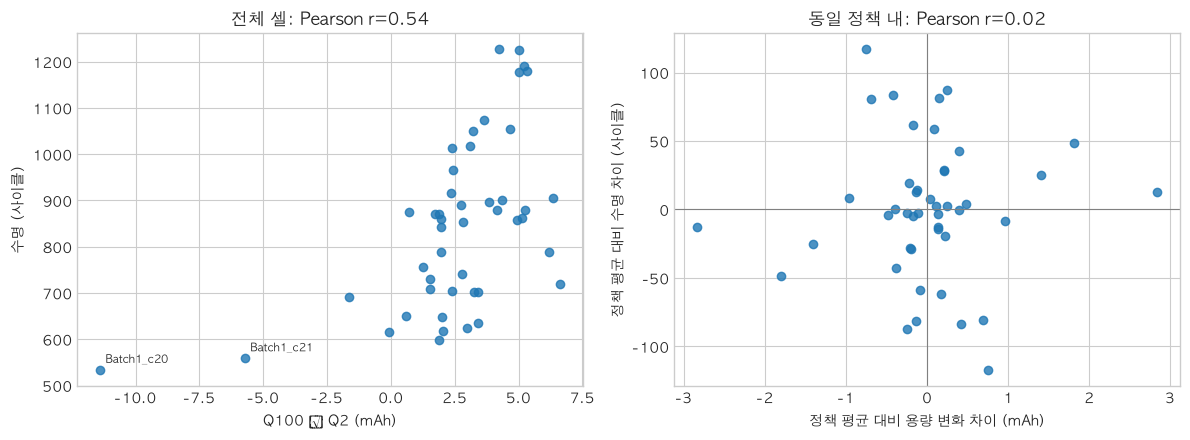

In [146]:
from scipy.stats import pearsonr, spearmanr

q12 = df_b1[["cell_id", "policy", "cycle_life"]].copy()
q12["용량 변화 (mAh)"] = df_b1["QDischarge"].map(lambda q: (q[99] - q[1]) * 1000)
q12["정책 내 용량 변화 차이"] = q12["용량 변화 (mAh)"] - q12.groupby("policy")["용량 변화 (mAh)"].transform("mean")
q12["정책 내 수명 차이"] = q12["cycle_life"] - q12.groupby("policy")["cycle_life"].transform("mean")
paired = q12[q12["policy"].map(q12["policy"].value_counts()) >= 2]
r_all = pearsonr(q12["용량 변화 (mAh)"], q12["cycle_life"])
r_rank = spearmanr(q12["용량 변화 (mAh)"], q12["cycle_life"])
r_within = pearsonr(paired["정책 내 용량 변화 차이"], paired["정책 내 수명 차이"])
display(pd.DataFrame({"비교": ["전체 Pearson", "전체 Spearman", "동일 정책 내 Pearson"],
                      "셀 수": [len(q12), len(q12), len(paired)],
                      "상관계수": [r_all.statistic, r_rank.statistic, r_within.statistic]}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].scatter(q12["용량 변화 (mAh)"], q12["cycle_life"], alpha=0.8)
axes[0].set(xlabel="Q100 − Q2 (mAh)", ylabel="수명 (사이클)", title=f"전체 셀: Pearson r={r_all.statistic:.2f}")
for _, row in q12[q12["cell_id"].isin(["Batch1_c20", "Batch1_c21"])].iterrows():
    axes[0].annotate(row["cell_id"], (row["용량 변화 (mAh)"], row["cycle_life"]), xytext=(4, 5), textcoords="offset points", fontsize=8)
axes[1].scatter(paired["정책 내 용량 변화 차이"], paired["정책 내 수명 차이"], alpha=0.8)
axes[1].axhline(0, color="gray", linewidth=0.8)
axes[1].axvline(0, color="gray", linewidth=0.8)
axes[1].set(xlabel="정책 평균 대비 용량 변화 차이 (mAh)", ylabel="정책 평균 대비 수명 차이 (사이클)", title=f"동일 정책 내: Pearson r={r_within.statistic:.2f}")
fig.tight_layout()
fig.savefig(os.path.join(project_root, "results", "q1_q2_capacity_change_vs_life.png"), dpi=160)
plt.show()


### 관측과 한계

- Batch 1 전체 46셀에서 초기 용량 변화량과 수명은 **Pearson r=0.540**, **Spearman ρ=0.566**으로 양의 상관을 보인다. 두 최단수명 셀(`c20`, `c21`)을 제외해도 Pearson r은 약 **0.484**다.
- 같은 정책을 적용한 셀만 정책 평균에서 벗어난 정도로 비교하면 **45셀, Pearson r=0.024**다. 정책별 셀 수가 대부분 2개여서 이 값만으로 관계가 없다고 결론낼 수 없지만, 전체 상관에는 **충전 정책 차이의 영향이 섞였을 가능성**이 크다.
- 초기 용량 변화량은 피처 후보로 남긴다. 독립적인 예측력은 Batch 1 내부 검증에서 정책 정보를 고려해 평가한다. Batch 2 라벨은 이 판단에 사용하지 않는다.


## 11. Q3·Q4 추가 분석 범위

Cycle 100−10의 전압별 용량 변화와 충전 정책을 비교한다. Batch 1·2·3 결과는 기술적 EDA이며 모델 선택은 Batch 1 내부 검증으로 수행한다. 코드와 실행 출력은 별도 `01_EDA_Q3-Q4.ipynb`에서 검증한 내용을 통합했다. 추가 EDA에 Batch 1 전체 라벨이 사용됐으므로 기존 Hold-out을 탐색에서 완전히 격리된 검증셋으로 표현하지 않는다.


In [147]:
from pathlib import Path
import sys, re
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
assert (ROOT / "src/preprocess.py").exists(), "프로젝트 루트 또는 notebooks에서 실행하세요."
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.preprocess import load_batch_summary

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["font.family"] = "AppleGothic" if sys.platform == "darwin" else "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False
pd.set_option("display.max_rows", 90)
FILES = {
    "Batch1": ROOT / "data/2017-05-12_batchdata_updated_struct_errorcorrect.mat",
    "Batch2": ROOT / "data/2018-02-20_batchdata_updated_struct_errorcorrect.mat",
    "Batch3": ROOT / "data/2018-04-12_batchdata_updated_struct_errorcorrect.mat",
}
OUT = ROOT / "results/q3_q4"
OUT.mkdir(parents=True, exist_ok=True)
summaries = {name: load_batch_summary(path, name) for name, path in FILES.items()}
split = pd.read_csv(ROOT / "results/train_val_split_cells.csv")
train_ids = set(split.loc[split["split"] == "train", "cell_id"])
assert len(train_ids) == 36


### Q3: 계산 정의와 원본 검증

`ΔQ(V) = Qdlin(Cycle 100) − Qdlin(Cycle 10)`을 동일한 `Vdlin` 위치에서 계산한다. `V`는 원시 시간 기록의 전압이므로 `Qdlin`의 공통 축으로 사용하지 않는다. 이미 보간된 값을 다시 보간하지 않는다.

확인 항목은 사이클 번호 대응, summary와 상세 사이클 수, 상세 Qd 최댓값과 summary 방전용량의 일치, 전압 축 단조성·길이·유한성이다. 분산은 전압 축의 1,000개 값에 대한 `np.var(..., ddof=0)`이며 `log10(분산)`을 후보로 계산한다. 0 또는 비유한 분산은 로그 계산에서 제외하고 사유를 남긴다. 이 값은 전압에 따른 곡선 모양의 변화량이지 물리적 열화 원인 자체는 아니다.


In [148]:
q3_rows, audit_rows, curves = [], [], {}
for batch_name, path in FILES.items():
    with h5py.File(path, "r") as f:
        batch = f["batch"]
        for _, row in summaries[batch_name].iterrows():
            i = int(row["cell_idx"])
            detail = f[batch["cycles"][i, 0]]
            voltage = f[batch["Vdlin"][i, 0]][()].ravel().astype(float)
            positions = [np.flatnonzero(row["cycles"] == cycle) for cycle in (10, 100)]
            reasons = []
            if not all(len(pos) == 1 for pos in positions):
                reasons.append("Cycle 10/100 누락 또는 중복")
            if detail["Qdlin"].shape[0] != len(row["cycles"]):
                reasons.append("summary/상세 사이클 수 불일치")
            if not np.isfinite(voltage).all() or not (np.all(np.diff(voltage) < 0) or np.all(np.diff(voltage) > 0)):
                reasons.append("전압 축 비유한 또는 비단조")
            qs = []
            if not reasons:
                for pos in positions:
                    j = int(pos[0])
                    q = f[detail["Qdlin"][j, 0]][()].ravel().astype(float)
                    raw_q = f[detail["Qd"][j, 0]][()].ravel()
                    if len(q) != len(voltage) or not np.isfinite(q).all():
                        reasons.append("Qdlin 길이/유한성 오류")
                    if not np.isclose(np.max(raw_q), row["QDischarge"][j], atol=1e-6, rtol=0):
                        reasons.append("상세 Qd/summary 값 불일치")
                    qs.append(q)
            variance = np.nan
            if not reasons:
                delta = qs[1] - qs[0]
                variance = float(np.var(delta, ddof=0))
                if not np.isfinite(variance) or variance <= 0:
                    reasons.append("분산 0 또는 비유한")
            passed = not reasons
            audit_rows.append({"batch": batch_name, "cell_id": row["cell_id"],
                "label_valid": bool(np.isfinite(row["cycle_life"]) and row["cycle_life"] > 0),
                "points": len(voltage), "voltage_min": voltage.min(), "voltage_max": voltage.max(),
                "passed": passed, "reason": "; ".join(reasons)})
            if passed:
                curves[row["cell_id"]] = (voltage, delta)
                q3_rows.append({"batch": batch_name, "cell_id": row["cell_id"], "policy": row["policy"],
                    "cycle_life": row["cycle_life"], "delta_q_mean": float(delta.mean()),
                    "delta_q_min": float(delta.min()), "delta_q_var": variance,
                    "delta_q_log_var": np.log10(variance)})
audit = pd.DataFrame(audit_rows)
q3_all = pd.DataFrame(q3_rows)
q3 = q3_all.loc[np.isfinite(q3_all["cycle_life"]) & (q3_all["cycle_life"] > 0)].copy()
audit.to_csv(OUT / "q3_input_audit.csv", index=False)
q3.to_csv(OUT / "q3_cell_features.csv", index=False)
display(audit.groupby("batch").agg(검사_셀수=("cell_id", "size"), 통과_셀수=("passed", "sum"),
    라벨_보유수=("label_valid", "sum"), 포인트수=("points", "min"), 전압_하한=("voltage_min", "min"), 전압_상한=("voltage_max", "max")))
display(audit.loc[~audit["passed"]])
assert len(audit) == 139 and not audit["cell_id"].duplicated().any()
assert len(q3) == 129, "라벨 보유 셀의 계산 가능 수를 확인"
assert np.isfinite(q3["delta_q_log_var"]).all()


,검사_셀수,통과_셀수,라벨_보유수,포인트수,전압_하한,전압_상한
batch,,,,,,
Batch1,46,46,46,1000,2.0000,3.5000
Batch2,47,47,39,1000,2.0000,3.5000
Batch3,46,46,44,1000,2.0000,3.5000


,batch,cell_id,label_valid,points,voltage_min,voltage_max,passed,reason


## 12. Q3 곡선·통계값과 수명의 관계

색은 셀 수명을 나타낸다. 장수명은 >1,000, 단수명은 <500사이클로 기술하되 Batch 1에는 <500 셀이 없어 그 배치 안에서 장·단수명을 직접 비교할 수 없다. 500~1,000은 별도의 중간 구간이며 단수명으로 바꿔 부르지 않는다. 배치별 표본·정책 차이가 있으므로 전체 배치를 합친 상관만으로 후보를 선택하지 않는다.


/var/folders/gq/d77743ts4tq8208b52yk916c0000gn/T/ipykernel_46858/2621458519.py:12: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AppleGothic.
  fig.savefig(OUT / "q3_delta_q_curves.png", dpi=160, bbox_inches="tight")
/Users/skala_yh/DS_miniproject/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


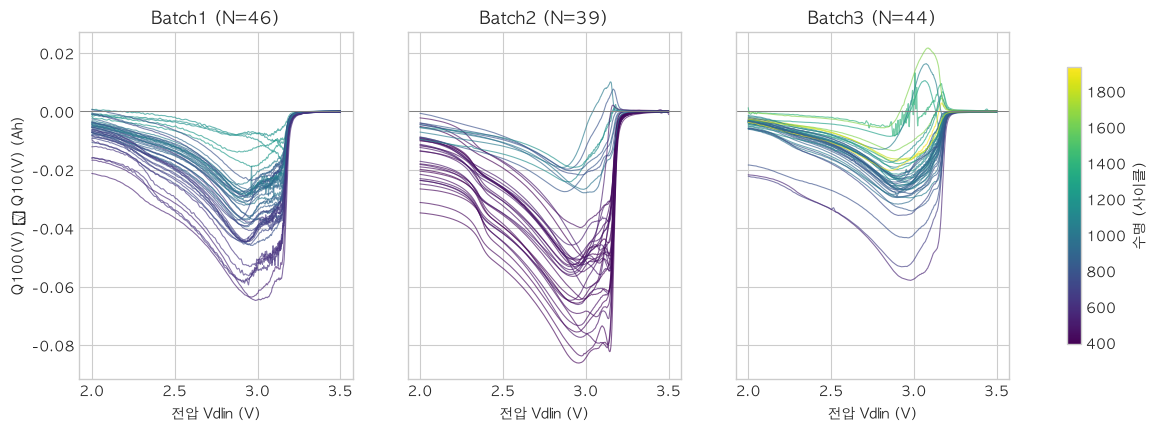

count  median     min     max
batch  수명 구간                                  
Batch1 500~1000     36 -3.7865 -4.1469 -3.3503
       >1000        10 -4.3107 -5.0149 -3.9387
Batch2 500~1000      8 -4.1533 -4.3645 -3.5089
       <500         28 -3.4461 -3.7073 -3.0859
       >1000         3 -4.2718 -4.4486 -4.2316
Batch3 500~1000     21 -4.0918 -4.2951 -3.4517
       >1000        23 -4.3167 -5.0989 -3.9823

,batch,feature,n,Pearson,Spearman
0,Batch1,delta_q_mean,46,0.8538,0.8281
1,Batch1,delta_q_min,46,0.8816,0.8500
2,Batch1,delta_q_log_var,46,-0.8861,-0.8712
3,Batch2,delta_q_mean,39,0.7671,0.6972
4,Batch2,delta_q_min,39,0.8185,0.6609
5,Batch2,delta_q_log_var,39,-0.9019,-0.7090
6,Batch3,delta_q_mean,44,0.6391,0.7561
7,Batch3,delta_q_min,44,0.6921,0.7760
8,Batch3,delta_q_log_var,44,-0.7019,-0.7972


Batch 1 Train 36셀만의 참고 상관


,batch,feature,n,Pearson,Spearman
0,Batch1,delta_q_log_var,36,-0.8717,-0.8388


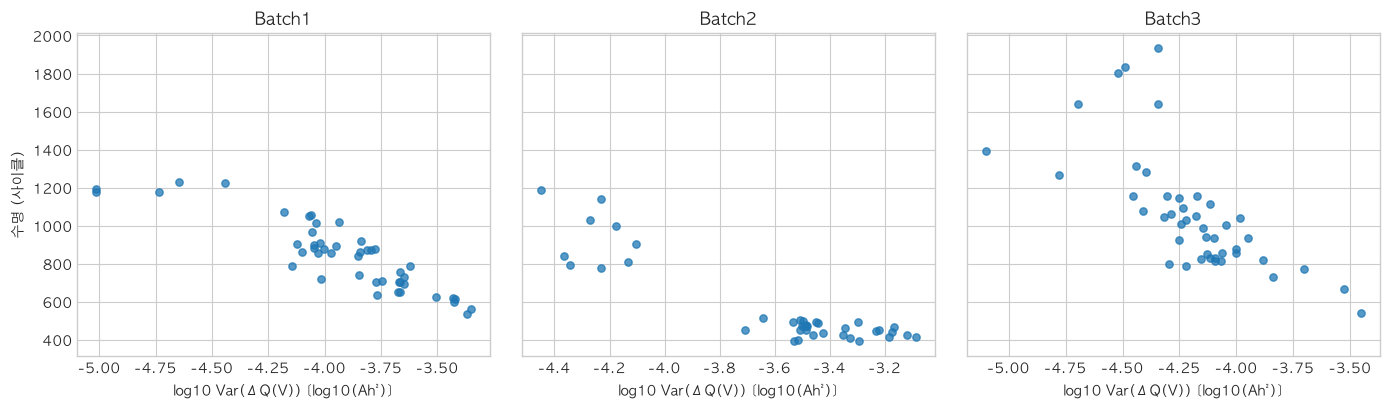

In [149]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)
norm = plt.Normalize(q3["cycle_life"].min(), q3["cycle_life"].max())
for ax, batch_name in zip(axes, FILES):
    part = q3[q3["batch"] == batch_name]
    for _, row in part.iterrows():
        v, delta = curves[row["cell_id"]]
        ax.plot(v, delta, color=plt.cm.viridis(norm(row["cycle_life"])), alpha=.65, linewidth=.8)
    ax.axhline(0, color="gray", linewidth=.7)
    ax.set(title=f"{batch_name} (N={len(part)})", xlabel="전압 Vdlin (V)")
axes[0].set_ylabel("Q100(V) − Q10(V) (Ah)")
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap="viridis"), ax=axes, label="수명 (사이클)", shrink=.8)
fig.savefig(OUT / "q3_delta_q_curves.png", dpi=160, bbox_inches="tight")
plt.show()

q3["수명 구간"] = np.select([q3.cycle_life < 500, q3.cycle_life > 1000], ["<500", ">1000"], default="500~1000")
display(q3.groupby(["batch", "수명 구간"], observed=True)["delta_q_log_var"].agg(["count", "median", "min", "max"]).round(4))

def correlation_table(df, features):
    rows = []
    for batch_name, part in df.groupby("batch"):
        for feature in features:
            pair = part[[feature, "cycle_life"]].dropna()
            rows.append({"batch": batch_name, "feature": feature, "n": len(pair),
                "Pearson": pair[feature].corr(pair["cycle_life"]),
                "Spearman": pair[feature].corr(pair["cycle_life"], method="spearman")})
    return pd.DataFrame(rows)
q3_corr = correlation_table(q3, ["delta_q_mean", "delta_q_min", "delta_q_log_var"])
display(q3_corr.round(4))
q3_corr.to_csv(OUT / "q3_correlations.csv", index=False)
print("Batch 1 Train 36셀만의 참고 상관")
display(correlation_table(q3[q3.cell_id.isin(train_ids)], ["delta_q_log_var"]).round(4))

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharey=True)
for ax, batch_name in zip(axes, FILES):
    part = q3[q3.batch == batch_name]
    ax.scatter(part.delta_q_log_var, part.cycle_life, alpha=.75, s=28)
    ax.set(title=batch_name, xlabel="log10 Var(ΔQ(V)) [log10(Ah²)]")
axes[0].set_ylabel("수명 (사이클)")
fig.tight_layout()
fig.savefig(OUT / "q3_log_variance_vs_life.png", dpi=160)
plt.show()


,batch,n,동일정책내_Pearson
0,Batch1,45,-0.0719
1,Batch2,39,-0.1967
2,Batch3,44,-0.3696


,delta_q_log_var,delta_q_mean,delta_q_min
delta_q_log_var,1.0000,-0.9262,-0.9470
delta_q_mean,-0.9262,1.0000,0.9925
delta_q_min,-0.9470,0.9925,1.0000


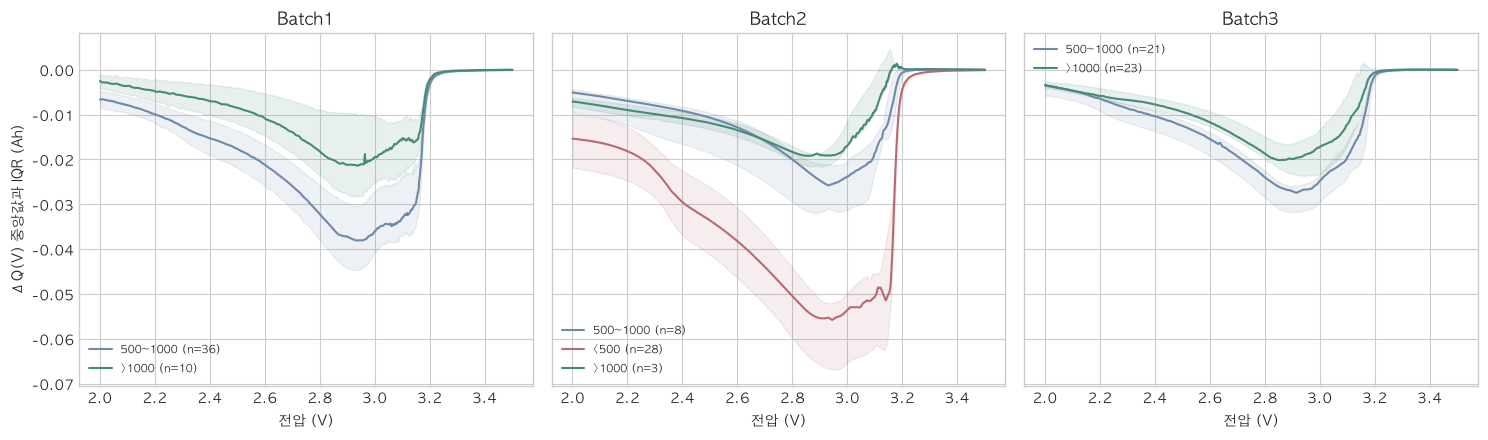

In [150]:
# 동일 정책 내 관계와 후보 간 중복을 추가 점검한다.
within_rows = []
for batch_name, part in q3.groupby("batch"):
    paired = part[part.policy.map(part.policy.value_counts()) >= 2].copy()
    x = paired.delta_q_log_var - paired.groupby("policy").delta_q_log_var.transform("mean")
    y = paired.cycle_life - paired.groupby("policy").cycle_life.transform("mean")
    within_rows.append({"batch": batch_name, "n": len(paired), "동일정책내_Pearson": x.corr(y)})
within = pd.DataFrame(within_rows)
display(within.round(4))
within.to_csv(OUT / "q3_within_policy_correlations.csv", index=False)
display(q3.loc[q3.batch == "Batch1", ["delta_q_log_var", "delta_q_mean", "delta_q_min"]].corr().round(4))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharex=True, sharey=True)
colors = {"<500": "#b66b74", "500~1000": "#6f89a8", ">1000": "#458a78"}
for ax, batch_name in zip(axes, FILES):
    for group, part in q3[q3.batch == batch_name].groupby("수명 구간"):
        v = curves[part.iloc[0].cell_id][0]
        assert all(np.array_equal(v, curves[cell][0]) for cell in part.cell_id)
        matrix = np.stack([curves[cell][1] for cell in part.cell_id])
        lower, median, upper = np.quantile(matrix, [.25, .5, .75], axis=0)
        ax.plot(v, median, color=colors[group], label=f"{group} (n={len(part)})")
        ax.fill_between(v, lower, upper, color=colors[group], alpha=.12)
    ax.set(title=batch_name, xlabel="전압 (V)")
    ax.legend(fontsize=8)
axes[0].set_ylabel("ΔQ(V) 중앙값과 IQR (Ah)")
fig.tight_layout()
fig.savefig(OUT / "q3_life_group_curves.png", dpi=160)
plt.show()


### Q3에 대한 답변과 판단

**초기 100사이클 안에서도 전압별 용량 곡선의 차이는 관측된다.** 공통 전압 축은 모든 셀에서 1,000포인트, 2.0~3.5V다. 139셀 모두 원본 대응 검사를 통과했고 라벨 보유 129셀의 로그 분산을 계산했다. 그림은 장수명·단수명 구간의 곡선 모양이 다르지만 일부 겹침과 국소적인 요철도 있음을 보여준다. 원본을 임의로 평활화하거나 요철을 오류로 제거하지 않았다.

- 로그 분산과 수명의 Pearson r는 Batch 1 **−0.886**, Batch 2 **−0.902**, Batch 3 **−0.702**다. Batch 1 Train 36셀에서도 **−0.872**다. 곡선 변화의 분산이 큰 셀일수록 수명이 짧은 관계가 관측된다.
- 그러나 동일 정책 평균을 뺀 Batch 1 45셀의 상관은 **−0.072**다. 정책당 대부분 2셀이라 강한 결론은 어렵지만, 전체 관계가 정책 차이를 반영할 가능성이 있다. 정책이 달라진 새 셀에 독립적으로 유용한지는 검증해야 한다.
- Batch 1의 ΔQ 평균·최솟값끼리 r=**0.993**, 로그 분산과 최솟값은 r=**−0.947**이다. 여러 통계값을 모두 넣으면 비슷한 정보를 중복할 수 있다.

**설계 제안:** 로그 분산 하나를 우선 추가 후보로 검토한다. 기존 요약 용량 변화만 보는 것보다 전압별 곡선 변화의 정보를 담을 수 있지만, 실제 개선 여부는 Batch 1 Train 내부 CV에서 비교한다. 이 EDA만으로 최종 피처 채택이나 목표 MAPE 달성을 주장하지 않는다. Batch 1에는 <500 셀이 없으므로 장·단수명 직접 비교를 수행했다고 표현하지 않는다.


## 13. Q4 충전 정책과 수명의 관계

정책 문자열의 첫 C-rate, 전환 SOC(%), 두 번째 C-rate, `newstructure` 표기를 구분한다. 예를 들어 `5.4C(50%)-3C`의 첫 단계와 `5.4C(80%)-5.4C`는 첫 C-rate가 같아도 전류 패턴이 다르다. 정책별 셀 수·평균·중앙값·범위를 함께 보고, 첫 C-rate만으로 충전 조건 전체를 대표하지 않는다.

열화 관련 보조 자료는 초기 100사이클 내 방전용량 변화와 최고온도다. 초기 용량 증가를 이미 관찰했으므로 이 변화량을 전체 수명의 열화 속도로 해석하지 않는다. 상세 전류는 **A 단위**로 그린다. C-rate로 환산하려면 기준 용량 정의가 필요하다.


In [151]:
policy_pattern = re.compile(r"^(?P<c1>\d+(?:\.\d+)?)C\((?P<soc>\d+(?:\.\d+)?)%\)-(?P<c2>\d+(?:\.\d+)?)C(?P<suffix>.*)$")
q4_rows = []
for batch_name, summary in summaries.items():
    for _, row in summary.iterrows():
        if not np.isfinite(row.cycle_life) or row.cycle_life <= 0:
            continue
        m = policy_pattern.fullmatch(row.policy)
        assert m, f"미해석 정책: {row.policy}"
        positions = [np.flatnonzero(row.cycles == c) for c in (2, 100)]
        assert all(len(pos) == 1 for pos in positions)
        i2, i100 = [int(pos[0]) for pos in positions]
        early = (row.cycles >= 2) & (row.cycles <= 100)
        q4_rows.append({"batch": batch_name, "cell_id": row.cell_id, "policy": row.policy,
            "cycle_life": row.cycle_life, "c1": float(m['c1']), "switch_soc": float(m['soc']),
            "c2": float(m['c2']), "newstructure": 'newstructure' in m['suffix'],
            "delta_q_100_2_mAh": 1000 * (row.QDischarge[i100] - row.QDischarge[i2]),
            "tmax_2_100": float(np.max(row.Tmax[early]))})
q4 = pd.DataFrame(q4_rows)
assert len(q4) == 129 and q4.cell_id.is_unique
q4.to_csv(OUT / "q4_cell_features.csv", index=False)
policy_summary = q4.groupby(["batch", "policy"], sort=True).agg(
    셀수=("cell_id", "size"), 평균수명=("cycle_life", "mean"), 중앙값=("cycle_life", "median"),
    최소수명=("cycle_life", "min"), 최대수명=("cycle_life", "max"),
    초기용량변화_mAh=("delta_q_100_2_mAh", "mean"), 최고온도평균=("tmax_2_100", "mean"))
display(policy_summary.round(3))
policy_summary.to_csv(OUT / "q4_policy_summary.csv")
q4_corr = correlation_table(q4, ["c1", "c2", "switch_soc", "delta_q_100_2_mAh", "tmax_2_100"])
display(q4_corr.round(4))
q4_corr.to_csv(OUT / "q4_correlations.csv", index=False)
print("Batch 1 Train 36셀의 정책 변수 참고 상관")
display(correlation_table(q4[q4.cell_id.isin(train_ids)], ["c1", "c2", "switch_soc"]).round(4))


셀수      평균수명       중앙값      최소수명  \
batch  policy                                                          
Batch1 3.6C(80%)-3.6C                3 1182.0000 1179.0000 1177.0000   
       4.4C(80%)-4.4C                1 1074.0000 1074.0000 1074.0000   
       4.8C(80%)-4.8C                2  753.0000  753.0000  636.0000   
       4C(80%)-4C                    2 1226.5000 1226.5000 1226.0000   
       5.4C(40%)-3.6C                2  966.5000  966.5000  879.0000   
       5.4C(50%)-3.6C                2  899.5000  899.5000  897.0000   
       5.4C(50%)-3C                  2  847.0000  847.0000  788.0000   
       5.4C(60%)-3.6C                2  859.5000  859.5000  857.0000   
       5.4C(60%)-3C                  2  799.5000  799.5000  719.0000   
       5.4C(70%)-3C                  2  739.5000  739.5000  691.0000   
       5.4C(80%)-5.4C                2  546.5000  546.5000  534.0000   
       6C(30%)-3.6C                  2  952.5000  952.5000  891.0000   
       6C(40%)-3.6C                  2  856.0000  856.0000  842.0000   
       6C(40%)-3C                    2  935.5000  935.5000  854.0000   
       6C(50%)-3.6C                  2  792.5000  792.5000  709.0000   
       6C(50%)-3C                    2  888.5000  888.5000  860.0000   
       6C(60%)-3C                    2  744.0000  744.0000  731.0000   
       7C(30%)-3.6C                  2  722.5000  722.5000  703.0000   
       7C(40%)-3.6C                  2  621.0000  621.0000  617.0000   
       7C(40%)-3C                    2  676.0000  676.0000  648.0000   
       8C(15%)-3.6C                  2 1008.5000 1008.5000  966.0000   
       8C(25%)-3.6C                  2  676.5000  676.5000  651.0000   
       8C(35%)-3.6C                  2  607.5000  607.5000  599.0000   
Batch2 3.6C(30%)-6C                  2  421.0000  421.0000  416.0000   
       3.6C(9%)-5C                   2  394.5000  394.5000  393.0000   
       4.65C(44%)-5C                 2  482.5000  482.5000  466.0000   
       4.65C(69%)-6C                 2  452.0000  452.0000  444.0000   
       4.8C(80%)-4.8C                5  483.6000  492.0000  437.0000   
       4.8C(80%)-4.8C-newstructure   3  871.6670  809.0000  777.0000   
       5.2C(50%)-4.25C               5  454.0000  449.0000  424.0000   
       5.2C(58%)-4C                  4  477.7500  483.0000  452.0000   
       5.2C(58%)-4C-newstructure     3  961.6670  904.0000  841.0000   
       5.6C(26%)-4.5C                6  448.5000  446.0000  412.0000   
       5.6C(26%)-4.5C-newstructure   3  991.3330  997.0000  791.0000   
       6C(60%)-3C                    2  400.0000  400.0000  392.0000   
Batch3 3.7C(31%)-5.9C-newstructure   3  660.0000  667.0000  541.0000   
       4.8C(80%)-4.8C-newstructure   6 1564.1670 1640.0000 1078.0000   
       5.3C(54%)-4C-newstructure     8 1074.3750 1051.0000  935.0000   
       5.6C(19%)-4.6C-newstructure   8 1001.3750 1038.0000  796.0000   
       5.6C(36%)-4.3C-newstructure   8  930.8750  890.5000  786.0000   
       5.9C(15%)-4.6C-newstructure   2  867.0000  867.0000  858.0000   
       5.9C(60%)-3.1C-newstructure   2  866.5000  866.5000  731.0000   
       5C(67%)-4C-newstructure       7 1105.7140 1009.0000  813.0000   

                                        최대수명  초기용량변화_mAh  최고온도평균  
batch  policy                                                     
Batch1 3.6C(80%)-3.6C              1190.0000      5.1900 35.2780  
       4.4C(80%)-4.4C              1074.0000      3.6530 34.6550  
       4.8C(80%)-4.8C               870.0000      2.6520 36.2750  
       4C(80%)-4C                  1227.0000      4.6280 33.6720  
       5.4C(40%)-3.6C              1054.0000      4.4090 35.9800  
       5.4C(50%)-3.6C               902.0000      4.1020 37.1240  
       5.4C(50%)-3C                 906.0000      6.2790 37.3720  
       5.4C(60%)-3.6C               862.0000      5.0390 37.3870  
       5.4C(60%)-3C                 880.0000      5.9310 38.1470  
       5.4C(70%)-3C                 788.0000      0.1640 3

,batch,feature,n,Pearson,Spearman
0,Batch1,c1,46,-0.5797,-0.4827
1,Batch1,c2,46,-0.0959,0.0474
2,Batch1,switch_soc,46,0.2346,0.1852
3,Batch1,delta_q_100_2_mAh,46,0.5395,0.5656
4,Batch1,tmax_2_100,46,-0.3998,-0.3224
5,Batch2,c1,39,0.1907,0.0551
6,Batch2,c2,39,-0.1163,-0.1188
7,Batch2,switch_soc,39,0.1161,0.2878
8,Batch2,delta_q_100_2_mAh,39,-0.1993,-0.0967
9,Batch2,tmax_2_100,39,-0.0163,-0.1517


Batch 1 Train 36셀의 정책 변수 참고 상관


,batch,feature,n,Pearson,Spearman
0,Batch1,c1,36,-0.5564,-0.4107
1,Batch1,c2,36,-0.1971,-0.0580
2,Batch1,switch_soc,36,0.1387,0.0856


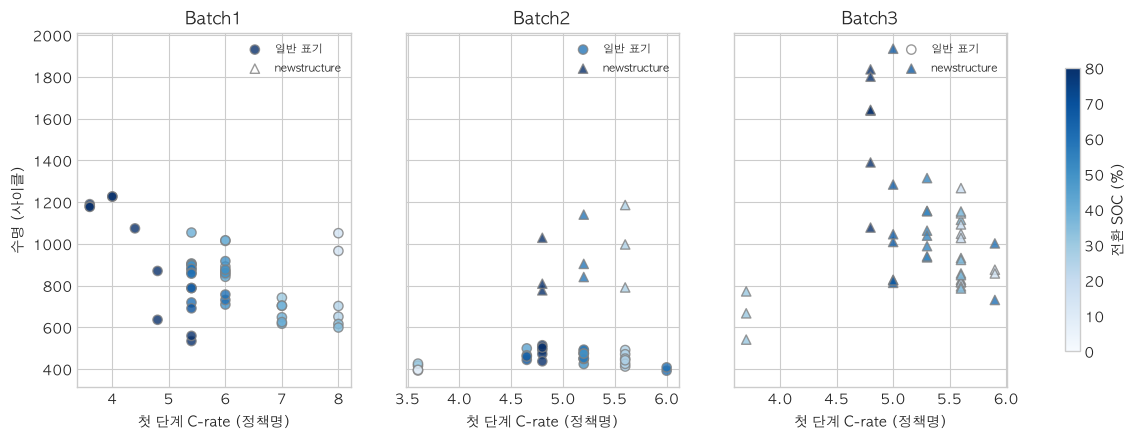

/var/folders/gq/d77743ts4tq8208b52yk916c0000gn/T/ipykernel_46858/4016860584.py:19: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  ax.boxplot(values, vert=False, tick_labels=[f"{policy} (n={len(v)})" for policy, v in zip(order, values)], showfliers=False)


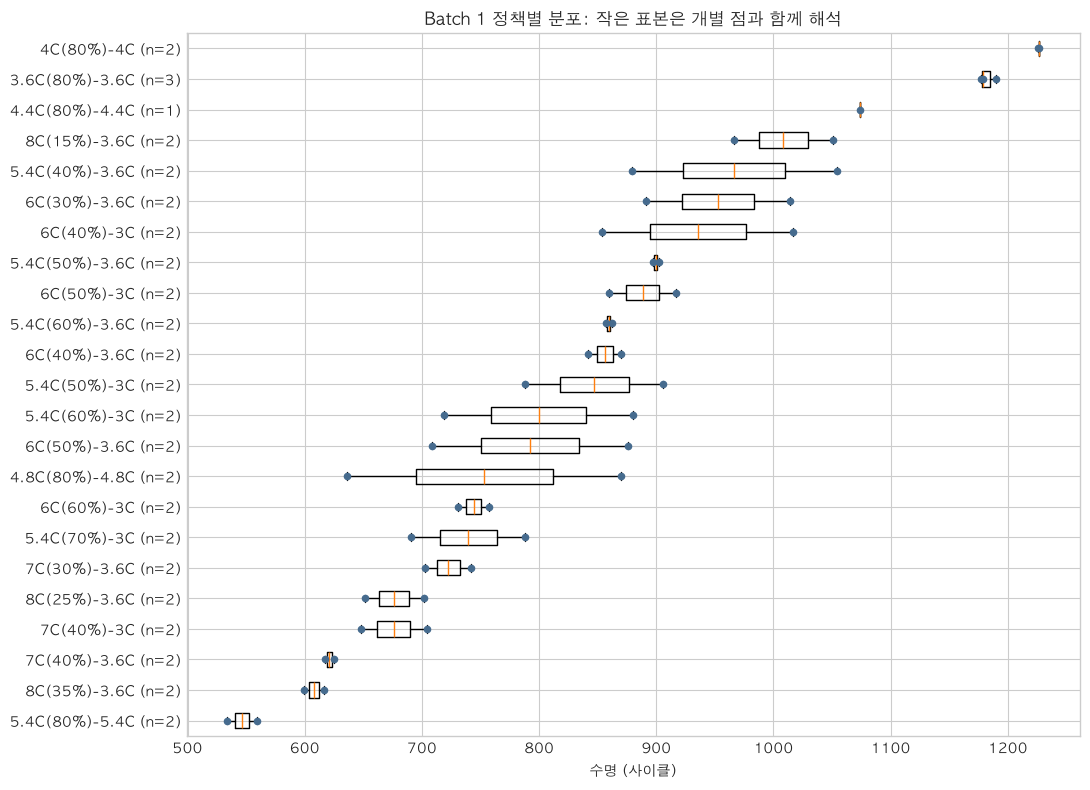

In [152]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharey=True)
for ax, batch_name in zip(axes, FILES):
    part = q4[q4.batch == batch_name]
    for flag, marker in [(False, "o"), (True, "^")]:
        sub = part[part.newstructure == flag]
        ax.scatter(sub.c1, sub.cycle_life, c=sub.switch_soc, cmap="Blues", vmin=0, vmax=80,
                   marker=marker, edgecolors="gray", s=45, alpha=.8, label="newstructure" if flag else "일반 표기")
    ax.set(title=batch_name, xlabel="첫 단계 C-rate (정책명)")
    ax.legend(fontsize=8)
axes[0].set_ylabel("수명 (사이클)")
fig.colorbar(plt.cm.ScalarMappable(norm=plt.Normalize(0, 80), cmap="Blues"), ax=axes, label="전환 SOC (%)", shrink=.8)
fig.savefig(OUT / "q4_c1_vs_life.png", dpi=160, bbox_inches="tight")
plt.show()

b1 = q4[q4.batch == "Batch1"]
order = b1.groupby("policy").cycle_life.mean().sort_values().index
fig, ax = plt.subplots(figsize=(11, 8))
values = [b1.loc[b1.policy == policy, "cycle_life"].to_numpy() for policy in order]
ax.boxplot(values, vert=False, tick_labels=[f"{policy} (n={len(v)})" for policy, v in zip(order, values)], showfliers=False)
for y, v in enumerate(values, 1):
    ax.scatter(v, np.full(len(v), y), s=20, color="#466b8e", zorder=3)
ax.set(xlabel="수명 (사이클)", title="Batch 1 정책별 분포: 작은 표본은 개별 점과 함께 해석")
fig.tight_layout()
fig.savefig(OUT / "q4_batch1_policy_distribution.png", dpi=160)
plt.show()


### 실제 전류 패턴 대조

Batch 1에서 첫 C-rate 최저·중간·최고 셀을 대표 예시로 선택한다. 대표 셀 3개는 전체 정책을 대표하는 통계 표본이 아니다. Cycle 10과 100의 충전 중 전류를 비교하여 정책 문자열이 실제 기록과 어떤 형태로 연결되는지 확인한다. 양수 전류를 충전 구간으로 표시하며 전류 원인을 단정하지 않는다.


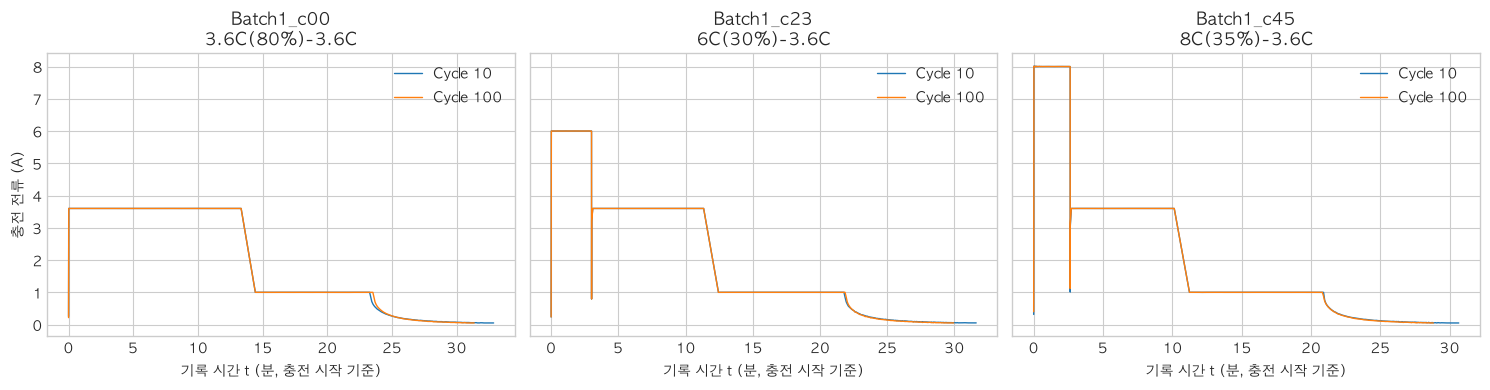

,cell_id,policy,cycle,max_charge_current_A
0,Batch1_c00,3.6C(80%)-3.6C,10,3.6010
1,Batch1_c00,3.6C(80%)-3.6C,100,3.6010
2,Batch1_c23,6C(30%)-3.6C,10,6.0020
3,Batch1_c23,6C(30%)-3.6C,100,6.0020
4,Batch1_c45,8C(35%)-3.6C,10,8.0070
5,Batch1_c45,8C(35%)-3.6C,100,8.0050


In [153]:
ordered = b1.sort_values(["c1", "cell_id"])
selected = ordered.iloc[[0, len(ordered)//2, len(ordered)-1]]
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
current_rows = []
with h5py.File(FILES["Batch1"], "r") as f:
    for ax, (_, row) in zip(axes, selected.iterrows()):
        source = summaries["Batch1"].loc[summaries["Batch1"].cell_id == row.cell_id].iloc[0]
        detail = f[f["batch"]["cycles"][int(source.cell_idx), 0]]
        for cycle in (10, 100):
            j = int(np.flatnonzero(source.cycles == cycle)[0])
            current = f[detail["I"][j, 0]][()].ravel()
            t = f[detail["t"][j, 0]][()].ravel()
            assert len(t) == len(current) and np.isfinite(t).all() and np.isfinite(current).all()
            charging = current > .05
            ax.plot(t[charging] - t[charging][0], current[charging], label=f"Cycle {cycle}", linewidth=1)
            current_rows.append({"cell_id": row.cell_id, "policy": row.policy, "cycle": cycle,
                                 "max_charge_current_A": float(current[charging].max())})
        ax.set(title=f"{row.cell_id}\n{row.policy}", xlabel="기록 시간 t (분, 충전 시작 기준)")
        ax.legend()
axes[0].set_ylabel("충전 전류 (A)")
fig.tight_layout()
fig.savefig(OUT / "q4_current_profiles.png", dpi=160)
plt.show()
display(pd.DataFrame(current_rows).round(3))


In [154]:
# 같은 첫 C-rate에서도 전체 정책과 수명은 다르다.
display(b1.loc[b1.c1 == 5.4].groupby("policy").cycle_life.agg(["count", "mean", "min", "max"]).round(2))
display(b1.groupby("c1").cycle_life.agg(["count", "mean", "median"]).round(2))
print("Batch 1: C1·초기 용량 변화·온도 관계")
display(b1[["c1", "delta_q_100_2_mAh", "tmax_2_100"]].corr().round(4))
print("Batch 1 정책별 표본 수 분포")
display(b1.policy.value_counts().value_counts().rename_axis("정책당_셀수").rename("정책수").sort_index())


,count,mean,min,max
policy,,,,
5.4C(40%)-3.6C,2,966.5000,879.0000,1054.0000
5.4C(50%)-3.6C,2,899.5000,897.0000,902.0000
5.4C(50%)-3C,2,847.0000,788.0000,906.0000
5.4C(60%)-3.6C,2,859.5000,857.0000,862.0000
5.4C(60%)-3C,2,799.5000,719.0000,880.0000
5.4C(70%)-3C,2,739.5000,691.0000,788.0000
5.4C(80%)-5.4C,2,546.5000,534.0000,559.0000


,count,mean,median
c1,,,
3.6000,3,1182.0000,1179.0000
4.0000,2,1226.5000,1226.5000
4.4000,1,1074.0000,1074.0000
4.8000,2,753.0000,753.0000
5.4000,14,808.2900,859.5000
6.0000,12,861.5000,865.0000
7.0000,6,673.1700,675.5000
8.0000,6,764.1700,676.5000


Batch 1: C1·초기 용량 변화·온도 관계


,c1,delta_q_100_2_mAh,tmax_2_100
c1,1.0000,-0.2202,0.4504
delta_q_100_2_mAh,-0.2202,1.0000,0.0240
tmax_2_100,0.4504,0.0240,1.0000


Batch 1 정책별 표본 수 분포


정책당_셀수
1     1
2    21
3     1
Name: 정책수, dtype: int64

### Q4에 대한 답변과 판단

**Batch 1에서는 첫 C-rate가 높을수록 수명이 짧아지는 전체 관계가 있지만, 모든 배치와 정책에 일률적으로 적용되지는 않는다.** 첫 C-rate와 수명의 Pearson r는 Batch 1 **−0.580**, Batch 2 **+0.191**, Batch 3 **−0.083**이다. 서로 다른 정책 구성과 `newstructure` 조건을 섞어 단순한 원인으로 해석할 수 없다.

- Batch 1에서 첫 단계가 모두 5.4C인 정책도 평균 수명이 **546.5~966.5사이클**로 다르다. 전환 SOC와 두 번째 C-rate까지 충전 조건으로 고려해야 한다.
- 첫 C-rate별 평균도 5.4C **808.3**, 6C **861.5**, 7C **673.2**, 8C **764.2사이클**로 단조 감소하지 않는다. 셀 수와 다른 조건이 달라 직접적인 속도 비교 실험으로 볼 수 없다.
- Batch 1의 첫 C-rate는 초기 최고온도와 r=**0.450**, 초기 용량 변화와 r=**−0.220**이다. 온도 관련 경로를 추가 확인할 단서지만 고속충전이 열화를 유발했다는 인과 증거는 아니다. 초기 용량 변화는 전체 수명의 열화 속도가 아니다.
- Batch 1 23개 정책 중 **21개는 2셀, 1개는 3셀, 1개는 1셀**이다. 박스플롯의 개별 점과 표본 수를 함께 봐야 한다. 대표 3셀의 Cycle 10·100 실제 전류 패턴은 유사하게 이어지지만 전체 셀의 패턴 안정성을 검증한 것은 아니다.

**설계 제안:** `charge_c1_rate` 단독 설명은 보강이 필요하다. 첫 C-rate·두 번째 C-rate·전환 SOC를 각각 검토하되 작은 표본에서 변수를 늘릴 가치는 Batch 1 내부 검증으로 결정한다. `newstructure`를 물리적 구조 변화라고 해석하지 않으며 의미 확인 전 인과 설명에 사용하지 않는다. 정책과 열화 관계를 더 깊게 확인하는 일은 후속 과제로 남길 수 있다.


### 모델 설계에 반영할 검증 기준

- **Q3:** 원본 검증을 통과한 ΔQ(V) 로그 분산은 기존 요약 용량 변화와 다른 곡선 정보를 담는 입력 후보다. Batch 1 Train 내부 CV에서 기준 피처에 추가했을 때 MAPE·분할 민감도가 개선되는지 확인한 뒤 채택한다. 현재는 계산 가능성과 관계를 확인한 단계다.
- **Q4:** 첫 C-rate·두 번째 C-rate·전환 SOC는 예측 시점에 알려진 조건 후보다. 첫 C-rate 단독 사용보다 전체 정책의 의미와 소표본을 고려해야 한다. 정책 인코딩은 학습 분할에서만 적합하고 새 정책 처리 규칙을 정한다.
- Batch 2·3의 수명과 상관은 배치별 차이를 설명하는 자료이며 모델 선택 기준으로 사용하지 않는다. Batch 2는 모델 확정 후 평가한다.
- Q3 로그 분산과 Q4 정책 변수는 입력 후보로 반영한다. 최종 피처 조합은 2일차 Batch 1 내부 검증으로 결정한다.


### Q2·Q3·Q4를 함께 해석하는 방법

- Q2의 `QDischarge`는 한 사이클의 총 방전용량이고 Q3의 `Qdlin(V)`는 공통 전압 축에서 보간한 용량 곡선이다. 비교 구간도 Q2는 Cycle 2~100, Q3는 Cycle 10~100으로 다르다. 총 방전용량이 증가하면서 전압별 ΔQ(V)는 음수일 수 있으므로 서로 모순이라고 볼 수 없다. 초기 총 용량 변화만으로 드러나지 않는 곡선 변화도 함께 확인한 것이다.
- Q2 용량 변화의 전체 상관 0.540·동일 정책 내 0.024와 Q3 로그 분산의 전체 −0.886·동일 정책 내 −0.072는 모두 정책 영향 가능성을 보여준다. 동일 정책당 대부분 2셀이라는 한계가 있어 독립 예측력은 학습 검증으로 판단한다.
- Q4는 Batch 2의 짧은 수명을 첫 C-rate 하나로 설명하기 어렵다는 근거를 보강한다. 회귀 과제와 Batch 1 내부 모델 선택·Batch 2 최종 평가라는 방향은 유지한다.


## 14. 예측 과제와 후보 피처 정의

- **과제 선택:** 초기 100사이클을 이용한 총수명 회귀. 가이드의 분류 기준은 `cycle_life >= 550`이며, Batch 1에서 550 미만이 1/46셀이라 이 분할로 분류를 안정적으로 학습·평가하기 어렵다. 회귀는 연속형 수명 예측이라는 과제 목적에도 맞는다.
- **입력·타깃:** Cycle 2~100 요약 측정값과 예측 시점에 알려진 충전 정책을 후보로 두고, 타깃은 `cycle_life`로 정한다. Batch 1의 Cycle 1 요약 0값은 사용하지 않는다. `log(cycle_life)`는 추후 비교할 타깃 변환 후보이며 채택하지 않았다.
- **후보와 최종 선택 구분:** 아래 정의표는 계산식·단위·검토 상태를 기록한다. 실제 피처 조합, 결측 처리, 스케일링과 정책 인코딩은 Batch 1 학습·검증에서 확정한다. Q3 미실시 피처와 사후 정보는 별도 표시한다.


In [155]:
# Step 6 후보 정의표: 관측 근거와 미확정 처리 기준을 분리한다.
candidate_features = [
    ("q_diff_100_2", "QDischarge", "Cycle 2, 100", "Q100 - Q2", "Ah",
     "수명과 r=0.540; 동일 정책 내 r=0.024로 정책 영향 가능", "스케일링·독립 예측력은 Train/Valid에서 검토", "후보"),
    ("ir_diff_100_2", "IR", "Cycle 2, 100", "IR100 - IR2", "Ω",
     "수명과 r=0.142; 대부분 증가값이 아니어서 물리적 의미 미확인", "측정값·분포 확인 후 사용 결정", "보류"),
    ("t_max_100", "Tmax", "Cycle 2~100", "max(Tmax[1:100])", "°C",
     "Batch 1 수명과 r=-0.400; 정책·다른 온도 변수 영향 미확인", "60°C 클리핑 미적용; 이상값 원본 확인", "후보"),
    ("delta_t_100", "Tmax, Tmin", "Cycle 2~100", "max(Tmax[1:100]) - min(Tmin[1:100])", "°C",
     "Tmax와 r=0.969로 중복 가능", "Tmax와 동시 사용 전 중복 검토", "보류"),
    ("ch_time_avg_min", "chargetime", "Cycle 2~100", "mean(chargetime[1:100])", "min",
     "Cycle 13 약 419분 기록 3셀의 평균에 영향; 원인 미확인", "원본 유지; 대체·중앙값 사용은 보류", "보류"),
    ("charge_c1_rate", "policy", "예측 시점에 알려진 정책", "정책 문자열의 첫 C-rate 파싱", "C-rate",
     "Q4 Batch 1 수명 r=-0.580; 다른 배치에는 동일 관계 없음", "두 번째 C-rate·전환 SOC와 함께 검토", "후보"),
    ("delta_q_log_var", "Qdlin, V", "Cycle 10, 100", "log10(Var(Q100(V) - Q10(V)))", "log(Ah²)",
     "Q3 원본 계산 통과; Batch 1 r=-0.886, 동일 정책 내 r=-0.072", "학습 내부 CV에서 독립 예측력·정책 영향 비교", "후보"),
    ("charge_c2_rate", "policy", "예측 시점에 알려진 정책", "두 번째 C-rate 파싱", "C-rate",
     "첫 C-rate가 같아도 전체 정책별 수명 차이; Batch 1 r=-0.096", "소표본에서 추가 변수 가치 CV 비교", "후보"),
    ("charge_switch_soc", "policy", "예측 시점에 알려진 정책", "전환 SOC 파싱", "%",
     "Q4 Batch 1 수명 r=0.235; 다른 충전 조건과 결합 검토", "소표본에서 추가 변수 가치 CV 비교", "후보"),
    ("n_cycles", "summary.cycle", "전체 기록", "기록 종료 시점 총 사이클 수", "cycles",
     "예측 시점 이후에만 알 수 있는 사후 정보", "모델 입력에서 제외", "제외"),
]
columns = ["피처명", "원본 필드", "계산 구간", "산출 수식", "단위", "EDA 근거 및 채택 이유", "처리 방안", "상태"]
df_candidate_features = pd.DataFrame(candidate_features, columns=columns)
candidate_features_path = os.path.join(project_root, "results", "candidate_features_definition.csv")
df_candidate_features.to_csv(candidate_features_path, index=False)
display(df_candidate_features[["피처명", "산출 수식", "단위", "상태", "EDA 근거 및 채택 이유"]])
print(f"후보 정의표 저장: {candidate_features_path}")


,피처명,산출 수식,단위,상태,EDA 근거 및 채택 이유
0,q_diff_100_2,Q100 - Q2,Ah,후보,수명과 r=0.540; 동일 정책 내 r=0.024로 정책 영향 가능
1,ir_diff_100_2,IR100 - IR2,Ω,보류,수명과 r=0.142; 대부분 증가값이 아니어서 물리적 의미 미확인
2,t_max_100,max(Tmax[1:100]),°C,후보,Batch 1 수명과 r=-0.400; 정책·다른 온도 변수 영향 미확인
3,delta_t_100,max(Tmax[1:100]) - min(Tmin[1:100]),°C,보류,Tmax와 r=0.969로 중복 가능
4,ch_time_avg_min,mean(chargetime[1:100]),min,보류,Cycle 13 약 419분 기록 3셀의 평균에 영향; 원인 미확인
5,charge_c1_rate,정책 문자열의 첫 C-rate 파싱,C-rate,후보,Q4 Batch 1 수명 r=-0.580; 다른 배치에는 동일 관계 없음
6,delta_q_log_var,log10(Var(Q100(V) - Q10(V))),log(Ah²),후보,"Q3 원본 계산 통과; Batch 1 r=-0.886, 동일 정책 내 r=-0.072"
7,charge_c2_rate,두 번째 C-rate 파싱,C-rate,후보,첫 C-rate가 같아도 전체 정책별 수명 차이; Batch 1 r=-0.096
8,charge_switch_soc,전환 SOC 파싱,%,후보,Q4 Batch 1 수명 r=0.235; 다른 충전 조건과 결합 검토
9,n_cycles,기록 종료 시점 총 사이클 수,cycles,제외,예측 시점 이후에만 알 수 있는 사후 정보


후보 정의표 저장: /Users/skala_yh/DS_miniproject/results/candidate_features_definition.csv


### 누수 방지와 다음 단계

- `cycle_life`는 타깃, `n_cycles`는 사후 기록이므로 입력에서 제외한다. 충전 정책은 예측 시점에 알려진 경우에만 후보로 사용한다.
- 셀 단위로 분할하고, 대체·스케일링·인코딩의 `fit`은 Batch 1 학습 분할에서만 수행한다. 처리 기준과 분할 비율·seed는 Step 7에서 확정한다.
- Batch 2 수명 분포는 Q1에서 열람했다. 그 결과로 후보를 선택·튜닝하지 않고 모델 확정 후 최종 평가에 사용한다.


## 15. 모델 및 검증 설계

- **확정한 분할:** Batch 1의 46셀을 `random_state=42`로 섞어 36셀 Train / 10셀 Validation으로 나누고 셀 ID를 저장한다. 같은 셀이 양쪽에 들어가지 않는지 검사한다.
- **이 분할의 한계:** 셀 ID 중복은 막지만 충전 정책의 중복까지 막지는 않는다. 정책별 일반화나 분할에 따른 성능 변동은 추가 평가가 필요하다. 분할을 검증 점수에 맞춰 다시 고르지 않는다.
- **가이드와의 차이:** 이번 진행 기준은 단일 셀 단위 Hold-out이다. 과제 가이드는 Train 내부 CV 평균도 요구하므로 CV는 **미실시**로 표기하고 제출 표의 Train 지표 정의를 확인한다.
- **학습 전처리:** 대체·스케일링·정책 인코딩을 사용할 경우 Train에만 `fit`, Validation/Test에는 `transform`한다. 아직 모델 전처리나 학습을 실행한 것은 아니다.
- **후보 모델:** Train 중앙값 DummyRegressor를 기준으로 두고, 규제 선형 모델과 제한된 트리 모델을 Batch 1 Validation에서 비교한다. 구체적 모델·하이퍼파라미터는 결과를 보기 전 범위를 정한다.
- **지표:** MAPE(%). Train 점수는 재예측 점수와 CV 평균을 구분한다. Valid−Train, Test−Valid, Test−목표(9.1%) 차이는 **%p**로 표시한다. Hold-out 반복 튜닝 시 Validation 점수도 낙관적으로 편향될 수 있다.
- **최종 평가:** Batch 2 라벨 보유 39셀은 모델·피처·튜닝을 확정한 후 한 번 평가한다. Q1에서 Batch 2 라벨 분포를 이미 확인했으므로 완전 블라인드 라벨 평가라고 부르지 않는다.


In [156]:
import pandas as pd
from sklearn.model_selection import train_test_split

manifest = pd.read_csv(os.path.join(project_root, "results", "clean_cells_manifest.csv"))
b1_cells = manifest.loc[manifest["status"] == "valid_train_holdout"].copy()
assert len(b1_cells) == 46 and b1_cells["cell_id"].is_unique
assert b1_cells["cycle_life"].notna().all()

train_cells, val_cells = train_test_split(b1_cells, test_size=0.2, random_state=42, shuffle=True)
train_ids, val_ids = set(train_cells["cell_id"]), set(val_cells["cell_id"])
assert not train_ids & val_ids
assert train_ids | val_ids == set(b1_cells["cell_id"])

split_df = b1_cells[["batch", "cell_id", "policy", "cycle_life"]].copy()
split_df["split"] = split_df["cell_id"].map(lambda x: "train" if x in train_ids else "val")
split_df = split_df.sort_values(["split", "cell_id"])
split_path = os.path.join(project_root, "results", "train_val_split_cells.csv")
split_df.to_csv(split_path, index=False)
summary = split_df.groupby("split")["cycle_life"].agg(["count", "mean", "median", "std", "min", "max"]).round(1)
train_policies = set(train_cells["policy"])
val_policies = set(val_cells["policy"])
print(summary)
print(f"셀 ID 교집합: {len(train_ids & val_ids)}개")
print(f"양쪽에 있는 충전 정책: {len(train_policies & val_policies)}종")
print(f"검증셋에만 있는 정책: {sorted(val_policies - train_policies)}")
print(f"분할 명세: {split_path}")


       count     mean   median      std      min       max
split                                                     
train     36 830.7000 849.5000 174.6000 534.0000 1190.0000
val       10 895.3000 874.5000 219.7000 616.0000 1227.0000
셀 ID 교집합: 0개
양쪽에 있는 충전 정책: 8종
검증셋에만 있는 정책: ['4C(80%)-4C']
분할 명세: /Users/skala_yh/DS_miniproject/results/train_val_split_cells.csv
